# Figures for the paper

## Loading packages and setups

In [2]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import torch
torch.use_deterministic_algorithms(True)

In [3]:
import io
import numpy as np
import pandas as pd
import palettable as pt
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.offsetbox import AnchoredText

In [4]:
from importlib.resources import files
plt.style.use(files('MatImba.utils').joinpath('ggplot_bw.mplstyle'))

In [5]:
from MatImba.utils import fd_optimal_bins
from MatImba.dataset import calc_dil, calc_comprehensive_imbalance

Helpher functions

In [6]:
import string
# Function to add the label consistently
def add_panel_label(ax, index, loc = (-0.1, 1.1), alphabet = string.ascii_lowercase):
    
    ax.text(*loc, f"{alphabet[index]}", 
            transform=ax.transAxes, 
            fontsize=10, va='top', ha='right')

## Fig 1. Distribution imbalance level of Matbench datasets

In [7]:
datasets = [
    'matbench_dielectric', 
    'matbench_jdft2d', 
    'matbench_steels', 
    'matbench_expt_gap', 
    'matbench_phonons',
    'matbench_log_gvrh',
    'matbench_log_kvrh',
    'matbench_glass', 
    'matbench_expt_is_metal',
    'matbench_perovskites',
    'matbench_mp_e_form',
    'matbench_mp_gap',
    'matbench_mp_is_metal',
]

In [8]:
def get_tarcol(df):
    return list(df)[-1]


def is_classification(folder):
    return folder in {'matbench_expt_is_metal', 'matbench_mp_is_metal', 'matbench_glass'}
regressions = [dataset for dataset in datasets if not is_classification(dataset)]
labels = [dataset.split('_', 1)[-1] for dataset in regressions]


def plot_distribution_with_metrics(
    data: np.ndarray, 
    ax: plt.Axes, 
    label: str = None, 
    show_kde: bool = True
) -> None:
    """
    Plots a histogram with Robust DIL metrics.
    Robust against non-numeric/missing data (Fixes TypeError).
    """
    # 1. Robust Data Cleaning
    # Flatten array
    raw_data = np.asarray(data).flatten()
    
    # FIX: Force conversion to numeric (float). 
    # 'coerce' turns strings/errors into NaNs, preventing crashes.
    clean_data = pd.to_numeric(raw_data, errors='coerce')
    
    # Now safe to check for NaNs
    data = clean_data[~np.isnan(clean_data)]
    
    if len(data) == 0:
        ax.text(0.5, 0.5, "No Valid Data", ha='center', va='center')
        return

    # 2. Plot Histogram
    counts, bins, patches = ax.hist(
        data, 
        bins='fd', 
        density=False, 
        color='#4393c3', 
        alpha=0.65, 
        edgecolor='None', 
        linewidth=0.5
    )
    
    # 3. (Optional) Add KDE curve
    if show_kde and len(data) > 1 and np.var(data) > 0:
        try:
            density = gaussian_kde(data)
            # Plot over actual data range
            xs = np.linspace(min(data), max(data), 200)
            ax.plot(xs, density(xs), color='#1f4e79', lw=1.5, label='KDE')
        except Exception:
            pass # Skip KDE if singular matrix (e.g. all values same)

    # 4. Calculate Metrics
    metrics = calc_comprehensive_imbalance(data)
    
    # 5. Create Text Box
    stats_text = (
        f"{label}\n"
        f"$h$: {metrics['DIL']: .3f}\n"
        # f"$G$: {metrics['Gini']: .3f}\n"
        f"$W_1$: {metrics['Wasserstein']: .3f}"
    )
    
    at = AnchoredText(
        stats_text,
        prop=dict(size=8, family='monospace'), 
        frameon=True,
        loc='upper right'
    )
    at.patch.set_boxstyle("round,pad=0.1,rounding_size=0.2")
    at.patch.set_alpha(0.25)
    at.patch.set_edgecolor('#d3d3d3')
    ax.add_artist(at)
    
    # 6. Formatting
    # ax.set_ylabel("Density")
    # ax.set_xlabel(label if label else "Target Value")

    return 

In [9]:
for i, (label, dataset) in enumerate(zip(labels, regressions)):
    globals()[label] = pd.read_csv(f'matbench_data/{label}.csv')
    target_col = get_tarcol(globals()[label])
    raw_data = np.asarray(globals()[label][[target_col]]).flatten()
    
    # Force conversion to numeric (float). 
    # 'coerce' turns strings/errors into NaNs, preventing crashes.
    clean_data = pd.to_numeric(raw_data, errors='coerce')
    
    # Now safe to check for NaNs
    data = clean_data[~np.isnan(clean_data)]
    metrics = calc_comprehensive_imbalance(data)
    metrics.update({'dataset':label, 'size': len(data)})
    
    if i==0:
        result_df = pd.DataFrame([metrics])
    else:
        result_df.loc[len(result_df)] = metrics

result_df = result_df[['dataset', 'size', 'DIL', 'Gini', 'KL_Div', 'Wasserstein']]
# result_df.to_csv('matbench_data/matbench_stats.csv', index = None)

In [10]:
from adjustText import adjust_text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Looks like you are using an old matplotlib version.
               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


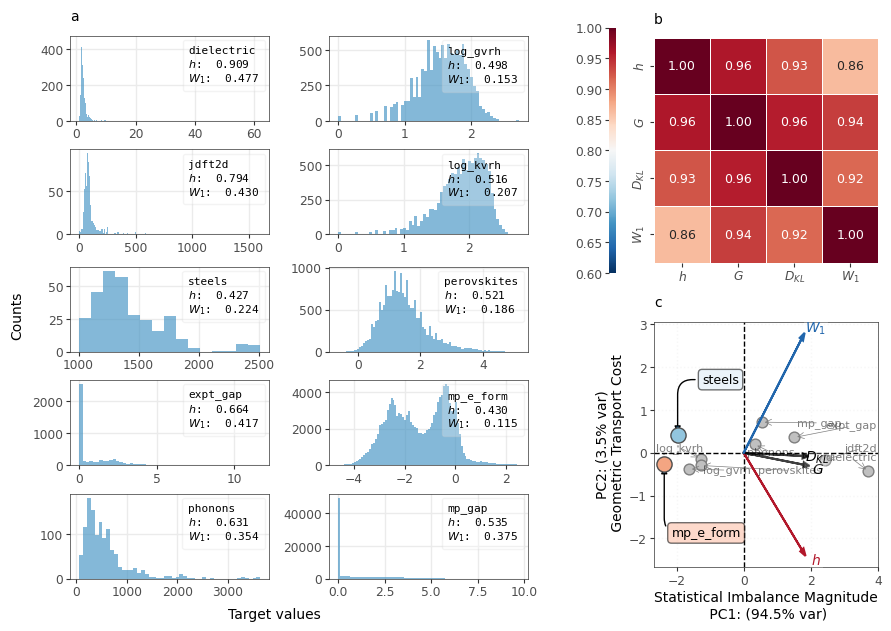

In [11]:
fig = plt.figure(figsize=(8.8, 6.2), layout = 'compressed')
subfigs = fig.subfigures(1, 2, width_ratios=[3.2, 2])
# --- First Subfigure: Columns 1 & 2 ---
# Create a 5x2 grid within this subfigure
gs_left = subfigs[0].add_gridspec(5, 2)

hst_axes = []
for col in range(2):
    for row in range(5):
        ax = subfigs[0].add_subplot(gs_left[row, col])
        hst_axes.append(ax)

for label, dataset, ax in zip(labels, regressions, hst_axes):
    # get_hst(globals()[label], ax = ax,  label = label)
    data = globals()[label].values
    plot_distribution_with_metrics(data, ax = ax, label = label)

subfigs[0].supxlabel('Target values', fontsize = 10)
subfigs[0].supylabel('Counts', fontsize = 10)

hst_axes[0].set_title('a', loc = 'left', fontsize = 10)

# --- Second Subfigure: Column 3 ---
# Create a 2x1 grid within this subfigure
gs_right = subfigs[1].add_gridspec(2, 1)

# Load data
# result_df = pd.read_csv('matbench_data/matbench_stats.csv')
df = result_df.rename(columns={'DIL': r'$h$', 'Gini': r'$G$', 'KL_Div': r'$D_{KL}$', 'Wasserstein': r'$W_1$'})
metrics = [r'$h$', r'$G$', r'$D_{KL}$', r'$W_1$']

cor_ax = subfigs[1].add_subplot(gs_right[0, 0])
# 1. Heatmap Plotting
corr_matrix = df[metrics].corr(method='pearson')
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', 
            vmin=0.6, vmax=1, square=True, linewidths=0.5, cbar=True, 
            ax=cor_ax, annot_kws={"size": 9}, cbar_kws={
                "shrink": 1.0, "pad": -0.09, "aspect": 40, "location": "left", 
            })

cor_ax.set_title('b', loc='left', fontsize = 10)

pca_ax = subfigs[1].add_subplot(gs_right[1, 0])

X = df[metrics]

# Normalize & PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
loadings = pca.components_.T

# Plot Datasets (Scatter)
texts = []
x_coords = []
y_coords = []
obstacle_points = [] # Holds coordinates for ALL points on the plot

# Plot Datasets (Scatter)
for i, row in df.iterrows():
    name = row['dataset']
    x, y = coords[i, 0], coords[i, 1]
    
    # 1. Track every single plot point as an unmovable layout obstacle
    obstacle_points.append([x, y])
    
    # Highlight key case studies
    if name =='steels':
        pca_ax.scatter(x, y, s=120, c='#92c5de', edgecolors='#4d4d4d', zorder=10)
        pca_ax.annotate(name, xy=(x, y), xytext = (x+1.28, y+1.3), fontsize=9, va = 'center', ha='center', 
                    arrowprops = dict(arrowstyle="-|>", connectionstyle="angle,angleA=0,angleB=90,rad=15"),
                    bbox=dict(boxstyle="round", fc = "#dceaf6", ec = "#000000", alpha = 0.55))
        pca_ax.plot([x, x], [0, y], 'k:', alpha=0.3)

    elif name == 'mp_e_form':
        pca_ax.scatter(x, y, s=120, c='#f4a582', edgecolors='#4d4d4d', zorder=10)
        pca_ax.annotate(
            name, xy=(x, y), xytext = (x+1.25, y-1.6), fontsize=9, va = 'center', ha='center',
            bbox=dict(boxstyle="round", fc = "#fcbba1", ec = "#000000", alpha = 0.55),
            arrowprops = dict(
                arrowstyle="-|>", connectionstyle="angle,angleA=0,angleB=90,rad=15"
            )
        )
        pca_ax.plot([x, x], [0, y], 'k:', alpha=0.3)
        
    else:
        # Background datasets
        pca_ax.scatter(x, y, s=60, c='silver', edgecolors='tab:gray')
        t = pca_ax.text(x, y, name, fontsize=8, alpha=0.5)
        texts.append(t)
        
        # Track original text anchors (1:1 with texts list length)
        x_coords.append(x)
        y_coords.append(y)

# 2. Run adjust_text using static_coords
adjust_text(
    texts, 
    x=x_coords,              
    y=y_coords,
    static_coords=np.array(obstacle_points),  
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    expand=(2.75, 2.75),     # Replaces expand_points. (X_multiplier, Y_multiplier)
    force_text=(5.3, 6.2), # Repulsion speed factor (X_force, Y_force)
    force_static=(3.5, 4.0), # Repulsion speed away from your data points!
)


# Axis Styling
pca_ax.axhline(0, color='k', lw=1, ls='--')
pca_ax.axvline(0, color='k', lw=1, ls='--')
pca_ax.set_xlabel(f"Statistical Imbalance Magnitude\n PC1: ({pca.explained_variance_ratio_[0]:.1%} var)", fontsize=10)
pca_ax.set_ylabel(f"PC2: ({pca.explained_variance_ratio_[1]:.1%} var)\n Geometric Transport Cost", fontsize=10)
# ax.set_title("Geometric vs. Statistical Imbalance Regimes", fontsize=16, weight='bold', pad=10)
pca_ax.grid(True, linestyle=':', alpha=0.4)


# Plot Vectors (Arrows)
scale = 3.5
for i, metric in enumerate(metrics):
    alpha = 1.0 if metric in [r'$h$', r'$W_1$'] else 0.75
    weight = 'bold' if metric in [r'$h$', r'$W_1$'] else 'normal'
    if metric == r'$W_1$':
        color = '#2166ac'
        tx, ty = loadings[i, 0]*scale*1.25, loadings[i, 1]*scale*1.1
        pca_ax.text(tx, ty, metric, color='#2166ac', ha='center', va='center', weight=weight, fontsize=10,
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.2), zorder=5)
    elif metric == r'$h$':
        color = '#b2182b'
        tx, ty = loadings[i, 0]*scale*1.25, loadings[i, 1]*scale*1.1
        pca_ax.text(tx, ty, metric, color='#b2182b', ha='center', va='center', weight=weight, fontsize=10,
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.2), zorder=5)
    else:
        color = 'k'
        # Text positioning
        tx, ty = loadings[i, 0]*scale*1.25, loadings[i, 1]*scale*1.35
        pca_ax.text(tx, ty, metric, color='k', ha='center', va='center', weight=weight, fontsize=10,
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.2), zorder=5)
    
    pca_ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale, 
         color=color, alpha=alpha, head_width=0.12, linewidth=1.5, zorder=5)

pca_ax.set_title('c', loc='left', fontsize = 10)

plt.savefig('figs/paper_final/matbench_dil.jpg', dpi = 600)

## Fig 2. Training trajectory

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch
from scipy.stats import pearsonr, spearmanr, kendalltau
import palettable.colorbrewer.diverging as cbd

# ==========================================
# 1. ROBUST PER-FOLD FILTERING (UNIFIED)
# ==========================================
def filter_outlier_runs(dfs, method_label, fold_id, metric='mae', 
                        explode_ratio=100.0,     
                        conv_ratio=5.25,          
                        warmup_epochs=20):       
    """
    Robustly filters runs ON A PER-FOLD BASIS using Relative metrics.
    """
    total_runs = len(dfs)
    if total_runs == 0: return []
    
    valid_final_scores = []
    valid_final_seras = []
    
    for df in dfs:
        if metric in df.columns and np.isfinite(df[metric]).all():
            valid_final_scores.append(df[metric].iloc[-5:].mean())
        if 'sera' in df.columns and np.isfinite(df['sera']).all():
            valid_final_seras.append(df['sera'].iloc[-5:].mean())
            
    if not valid_final_scores: return [] # FIX: Removed failsafe. If all invalid, return empty!

    median_final_metric = np.median(valid_final_scores)
    best_final_metric = np.min(valid_final_scores)
    median_final_sera = np.median(valid_final_seras) if valid_final_seras else None
    
    surviving = []
    for df in dfs:
        if not np.isfinite(df[metric]).all(): continue
            
        # 1. R2 Sanity Check (Catches fold_0_run1 which has R2 ~ 0.53)
        if 'r2_score' in df.columns:
            final_r2 = df['r2_score'].iloc[-5:].mean()
            if final_r2 < 0.65:
                continue # Model failed to learn general physics

        # 2. MAE Explosion Check (Catches fold_1_run4 which spikes MAE > 80.0)
        max_spike = df[metric].iloc[warmup_epochs:].max() if len(df) > warmup_epochs else df[metric].max()
        if max_spike > median_final_metric * explode_ratio:
            continue
            
        # 3. SERA Explosion Check (Catches fold_1_run4 SERA spike > 600,000)
        if median_final_sera is not None and 'sera' in df.columns:
            max_sera = df['sera'].iloc[warmup_epochs:].max() if len(df) > warmup_epochs else df['sera'].max()
            if max_sera > median_final_sera * max(explode_ratio, 100.0):
                continue
                
        # 4. Convergence Check
        final_val = df[metric].iloc[-5:].mean()
        if final_val > best_final_metric * conv_ratio:
            continue

        surviving.append(df)

    return surviving

def load_all_folds(method_label, search_pattern, metric, warmup_epochs=20, filter_runs = False, **filter_kwargs):
    """Loads all 25 runs and applies the filter independently to each fold."""
    files = glob.glob(search_pattern)
    if not files: return []
        
    from collections import defaultdict
    fold_files = defaultdict(list)
    
    for f in files:
        filename = os.path.basename(f)
        try:
            fold_id = "fold_" + filename.split("fold_")[1].split("_")[0]
            fold_files[fold_id].append(f)
        except:
            fold_files["unknown"].append(f)
            
    all_valid_dfs = []
    for fold_id, f_list in fold_files.items():
        dfs = []
        for f in f_list:
            try:
                df = pd.read_csv(f)
                df['run_id'] = os.path.basename(f)
                if len(df) > warmup_epochs + 5: dfs.append(df)
            except: pass
        if filter_runs:
            valid_dfs = filter_outlier_runs(
                dfs, method_label, fold_id, metric=metric, warmup_epochs=warmup_epochs,
                **filter_kwargs
            )
        else:
            valid_dfs = dfs
        all_valid_dfs.extend(valid_dfs)
            
    return all_valid_dfs

# ==========================================
# 2. ROW 1: UNIVERSAL DYNAMICS
# ==========================================
def plot_universal_dynamics_on_axes(axes_row, methods_config, metric='sera', filter_runs = False, **filter_kwargs):
    """Plots Loss, Awareness, and Phase Space on the top row."""
    ax_loss, ax_aware, ax_phase = axes_row
    DISCARD_EPOCHS = 20  
    SMOOTH_SPAN = 20     

    for config in methods_config:
        search_pattern = config['search_pattern']
        base_label = config['label']
        color = config['color']
        
        dfs = load_all_folds(base_label, search_pattern, metric=metric, warmup_epochs=DISCARD_EPOCHS, filter_runs = filter_runs, **filter_kwargs)
        if not dfs: continue
            
        final_label = f"{base_label} (n={len(dfs)})"

        # Process & Aggregate
        processed_dfs = []
        for df in dfs:
            sub_df = df.sort_values('epoch').copy()
            sub_df = sub_df[sub_df['epoch'] >= DISCARD_EPOCHS].copy()
            sub_df['metric_smooth'] = sub_df[metric].ewm(span=SMOOTH_SPAN, adjust=False).mean()
            sub_df['aware_smooth'] = sub_df['awareness'].ewm(span=SMOOTH_SPAN, adjust=False).mean()
            processed_dfs.append(sub_df)
        
        clean_df = pd.concat(processed_dfs)
        cols_to_agg = ['metric_smooth', 'aware_smooth']
        
        agg_df = clean_df.groupby('epoch')[cols_to_agg].agg(['mean', 'std']).reset_index()
        agg_df.columns = ['_'.join(col).strip() if col[1] else col[0] for col in agg_df.columns.values]
        
        x_epochs = agg_df['epoch']
        
        # Plot A: Loss
        y_mean = agg_df['metric_smooth_mean']
        y_std = agg_df['metric_smooth_std']
        ax_loss.plot(x_epochs, y_mean, color=color, label=final_label, linewidth=1.5)
        ax_loss.fill_between(x_epochs, y_mean - y_std, y_mean + y_std, color=color, alpha=0.15, linewidth=0)
        
        # Plot B: Awareness
        y_mean_aw = agg_df['aware_smooth_mean']
        y_std_aw = agg_df['aware_smooth_std']
        ax_aware.plot(x_epochs, y_mean_aw, color=color, label=final_label, linewidth=1.5)
        ax_aware.fill_between(x_epochs, y_mean_aw - y_std_aw, y_mean_aw + y_std_aw, color=color, alpha=0.15, linewidth=0)
        
        # Plot C: Phase Space
        ax_phase.plot(y_mean_aw, y_mean, color=color, linewidth=1.5, label=final_label, alpha=0.8, zorder=5)
        
        points_idx = np.linspace(0, len(agg_df)-1, 5, dtype=int)
        for i, idx in enumerate(points_idx):
            x_pt = y_mean_aw.iloc[idx]; y_pt = y_mean.iloc[idx]
            x_err = y_std_aw.iloc[idx]; y_err = y_std.iloc[idx]
            ax_phase.errorbar(x_pt, y_pt, xerr=x_err, yerr=y_err, 
                              color=color, ecolor=color, capsize=0, alpha=0.6, fmt='none', zorder=10)
            
        arrow_indices = np.linspace(0, len(agg_df)-1, 5, dtype=int) 
        points = np.array([y_mean_aw.values, y_mean.values]).T
        for i in range(len(arrow_indices)-1):
            idx_start, idx_end = arrow_indices[i], arrow_indices[i+1]
            start_pt, end_pt = points[idx_start], points[int(idx_start + (idx_end - idx_start) * 0.5)]
            arrow = FancyArrowPatch(posA=start_pt, posB=end_pt, 
                        arrowstyle='simple,head_length=6,head_width=6,tail_width=2', 
                        mutation_scale=0.7, 
                        facecolor=color,   
                        edgecolor='black', 
                        linewidth=0.75,       
                        alpha=0.9, 
                        zorder=15)
            ax_phase.add_patch(arrow)

        ax_phase.scatter(points[-1,0], points[-1,1], color=color, marker='o', s=60, edgecolors='k', zorder=25)

    # Formatting Top Row
    y_axis_name = metric.upper()
    ax_loss.set_ylabel(f"Validation {y_axis_name}")
    ax_loss.set_xlabel("Epoch")
    ax_loss.legend(fontsize=9)
    
    ax_aware.set_ylabel(r'$\alpha$')
    ax_aware.set_xlabel("Epoch")
    ax_aware.legend(fontsize=9)
    
    ax_phase.set_xlabel(r'$\alpha$')
    ax_phase.set_ylabel(y_axis_name)
    ax_phase.legend(fontsize=9)
    
    if metric == 'sera':
        ax_loss.set_yscale('log')
        ax_phase.set_yscale('log')

        plain_formatter = ticker.FuncFormatter(lambda x, pos: f"{x:.1f}")
        sci_formatter = ticker.LogFormatterSciNotation()

        for ax in [ax_loss, ax_phase]:
            plt.draw() 
            ymin, ymax = ax.get_ylim()
            
            if ymin > 100:
                ax.yaxis.set_major_formatter(sci_formatter)
                ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
            else:
                ax.yaxis.set_major_formatter(plain_formatter)
                ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0)))
                ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# ==========================================
# 3. ROW 2: BASIN & CORRELATION
# ==========================================
def plot_basin_on_ax(ax, methods_config, metric='mae'):
    """Plots the aggregated Basin KDE on a specific Matplotlib axis."""
    ANALYSIS_WINDOW = 75
    WARMUP_EPOCHS = 25 if metric == 'sera' else 5
    is_log_y = (metric == 'sera')
    legend_handles = []
    flatness_dict = {}
    
    for config in methods_config:
        label = config['label']
        color = config['color']
        search_pattern = config['search_pattern']
        
        # FIX 2: Ensure filter_runs=True is actually passed here!
        valid_dfs = load_all_folds(label, search_pattern, metric=metric, warmup_epochs=WARMUP_EPOCHS, filter_runs=True)
        if not valid_dfs: continue

        basin_data_y = []
        basin_data_x = [] 
        
        for df in valid_dfs:
            recent_df = df.iloc[-ANALYSIS_WINDOW:]
            y_vals = np.clip(recent_df[metric].values, a_min=1e-6, a_max=None)
            basin_data_y.extend(y_vals)
            basin_data_x.extend(recent_df['awareness'].values)
            
        y_std = np.std(basin_data_y)
        flatness_score = 1.0 / (y_std + 1e-8)

        flatness_dict[label] = flatness_score

        if flatness_score > 10000 or flatness_score < 0.01:
            formatted_score = f"{flatness_score:.1e}"
        else:
            formatted_score = f"{flatness_score:.2f}"
            
        display_label = f"{label} (Flatness: {formatted_score})"
        
        try:
            sns.kdeplot(
                x=basin_data_x, y=basin_data_y, ax=ax, 
                color=color, fill=True, alpha=0.3, levels=5, thresh=0.01, 
                log_scale=(False, is_log_y), 
            )
            sns.kdeplot(
                x=basin_data_x, y=basin_data_y, ax=ax, color=color, 
                levels=[0.5], linewidths=1, log_scale=(False, is_log_y),
                legend=False
            )
        except Exception as e:
            ax.scatter(basin_data_x, basin_data_y, color=color, alpha=0.1, s=5, label=label)
            
        ax.scatter(np.mean(basin_data_x), np.mean(basin_data_y), color=color, marker='o', s=60, edgecolors='k', zorder=10)

        proxy = mlines.Line2D([], [], color=color, marker='o', linestyle='None', mec = 'k',
                              markersize=60 ** 0.5, label=display_label)
        legend_handles.append(proxy)

    y_label = "Loss (SERA)" if metric == 'sera' else "Loss (MAE)"
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(y_label)

    if is_log_y:
        plt.draw() 
        ymin, ymax = ax.get_ylim()
        
        if ymin > 100:
            ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
            ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
        else:
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f"{val:.1f}"))
            ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
            ax.yaxis.set_minor_formatter(ticker.NullFormatter())
            
    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper right', fontsize=9)

    return flatness_dict
def alpha_sera_cor(ax, fold, folder, iqr_multiplier=3.0):
    """
    Plots Correlation for a specific fold.
    Uses all runs to capture global topology, relying purely on IQR to drop numerical explosions.
    """
    runs = [0, 1, 2, 3, 4]
    filenames = [f'fold_{fold}_run{r}_val_log.csv' for r in runs]
    
    if not os.path.exists(os.path.join(folder, filenames[0])):
        filenames = [f'fold_{fold}_run{r}_val_log (1).csv' for r in runs]

    LOG_FILES = [os.path.join(folder, f) for f in filenames]
    
    df_list = []
    for i, f in enumerate(LOG_FILES):
        try:
            temp_df = pd.read_csv(f)
            temp_df['run_id'] = f"Run {runs[i]}"
            df_list.append(temp_df)
        except FileNotFoundError: pass

    if not df_list: return 
    
    all_data = pd.concat(df_list, ignore_index=True)

    # Point-level IQR filtering to remove isolated mathematical explosions
    Q1 = all_data['sera'].quantile(0.25)
    Q3 = all_data['sera'].quantile(0.75)
    IQR = Q3 - Q1
    threshold = Q3 + (iqr_multiplier * IQR)
    clean_data = all_data[all_data['sera'] <= threshold].copy()

    x = clean_data['awareness'].values
    y = clean_data['sera'].values

    p_corr, _ = pearsonr(x, y)
    s_corr, _ = spearmanr(x, y)
    k_corr, _ = kendalltau(x, y)
    colormap=cbd.RdGy_8.mpl_colors
    
    sns.scatterplot(
        data=clean_data, x='awareness', y='sera', 
        hue='run_id', alpha=0.5, palette=colormap,   
        edgecolor=None, s=15, legend=False, ax=ax
    )
    
    sns.regplot(
        data=clean_data, x='awareness', y='sera', 
        scatter=False, color='#4d4d4d', line_kws={'linestyle': '--', 'linewidth': 2}, ax=ax
    )
    
    ax.set_xlabel(r'$\alpha$', fontsize=10)
    ax.set_ylabel('SERA', fontsize=10)
    ax.set_yscale('log')
    
    plt.draw()
    ymin, ymax = ax.get_ylim()

    if ymin > 100:
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
    else:
        plain_formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1f}")
        ax.yaxis.set_major_formatter(plain_formatter)
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    stats_text = (f"Pearson ($r$): {p_corr:.3f}\n"
                  f"Spearman ($\\rho$): {s_corr:.3f}\n"
                  f"Kendall ($\\tau$): {k_corr:.3f}")
    ax.text(0.05, 0.10, stats_text, transform=ax.transAxes, fontsize=9, 
            va='bottom', ha='left')

# ==========================================
# 4. MASTER EXECUTION
# ==========================================
def generate_analysis_figure(dataset='phonons', methods_config = None, result_dir='experiments/final', primary_metric='mae', filter_runs = False, filename=None, **filter_kwargs):
    sns.set_context("paper")

    if methods_config is None:
        methods_config = [
            {
                'label': 'DILA',
                'color': '#ff7f0e',
                'search_pattern': f"{result_dir}/{dataset}/smooth_dila_hpo/fold_*_run*_val_log*.csv"
            },
            {
                'label': 'Control',
                'color': '#4d4d4d',
                'search_pattern': f"{result_dir}/{dataset}/control/fold_*_run*_val_log*.csv"
            }
        ] 
    
    fig, (axes_row1, axes_row2) = plt.subplots(nrows=2, ncols=3, figsize=(9, 6), layout='compressed')
    
    # --- ROW 1: Universal Dynamics ---
    plot_universal_dynamics_on_axes(axes_row1, methods_config, metric=primary_metric, filter_runs=True, **filter_kwargs)
    
    # --- ROW 2: Basins & Correlation ---
    # Panel 2.1: Universal MAE Basin 
    mae_flatness = plot_basin_on_ax(axes_row2[0], methods_config, metric='mae')
    
    # Panel 2.2: Universal SERA Basin 
    sera_flatness = plot_basin_on_ax(axes_row2[1], methods_config, metric='sera')
    
    # Panel 2.3: Correlation (Specific Fold)
    dila_folder = f"{result_dir}/{dataset}/smooth_dila_hpo"
    alpha_sera_cor(axes_row2[2], fold=0, folder=dila_folder)
    
    start = ord('a')
    for i, ax in enumerate(axes_row1):
        ax.set_title(chr(start + i), loc='left', fontsize=9) 
    for i, ax in enumerate(axes_row2):
        ax.set_title(chr(start + i + 3), loc='left', fontsize=9) 
    
    filename = f"figs/paper_final/{dataset}_unified_analysis.jpg" if filename is None else filename
    os.makedirs('figs/paper_final', exist_ok=True)
    plt.savefig(filename, dpi=600)
    plt.show()
    print(f"Saved unified analysis figure to {filename}")
    return mae_flatness, sera_flatness

### CV

In [14]:
all_flatness_data = {}

# 1. Run and collect log_kvrh
print("\nProcessing log_kvrh...")
m_flat, s_flat = generate_analysis_figure(dataset='log_kvrh', primary_metric='sera')
all_flatness_data['log_kvrh'] = {'mae': m_flat, 'sera': s_flat}

# 2. Run and collect log_gvrh
print("\nProcessing log_gvrh...")
m_flat, s_flat = generate_analysis_figure(dataset='log_gvrh', primary_metric='sera')
all_flatness_data['log_gvrh'] = {'mae': m_flat, 'sera': s_flat}

# 3. Run and collect perovskites
print("\nProcessing perovskites...")
m_flat, s_flat = generate_analysis_figure(dataset='perovskites', primary_metric='sera', filter_runs=True)
all_flatness_data['perovskites'] = {'mae': m_flat, 'sera': s_flat}

# 4. Run and collect phonons
print("\nProcessing phonons...")
phonons_config = [
    {
        'label': 'DILA',
        'color': '#ff7f0e',
        'search_pattern': "experiments/final/phonons/smooth_dila/fold_*_run*_val_log*.csv"
    },
    {
        'label': 'Control',
        'color': '#4d4d4d',
        'search_pattern': "experiments/final/phonons/control/fold_*_run*_val_log*.csv"
    }
]
m_flat, s_flat = generate_analysis_figure(dataset='phonons', methods_config=phonons_config, primary_metric='sera', filter_runs=True)
all_flatness_data['phonons'] = {'mae': m_flat, 'sera': s_flat}

# ---------------------------------------------------------
# COMPILE THE COMBINED LATEX TABLE
# ---------------------------------------------------------
def fmt_latex(val):
    """Helper to format numbers cleanly for LaTeX."""
    if pd.isna(val): return "-"
    if val > 10000 or val < 0.01:
        base, exp = f"{val:.1e}".split('e')
        return f"${base} \\times 10^{{{int(exp)}}}$"
    return f"{val:.2f}"

latex_str = "\\begin{table}[h]\n\\centering\n\\begin{tabular}{llcc}\n\\toprule\n"
latex_str += "Dataset & Method & MAE Flatness ($\\uparrow$) & SERA Flatness ($\\uparrow$) \\\\\n\\midrule\n"

for dataset, data in all_flatness_data.items():
    dataset_formatted = dataset.replace('_', '\\_')
    methods = list(data['mae'].keys())
    
    for i, method in enumerate(methods):
        m_flat = data['mae'].get(method, np.nan)
        s_flat = data['sera'].get(method, np.nan)
        
        # Only print the dataset name on the first row of its group
        ds_col = f"\\texttt{{{dataset_formatted}}}" if i == 0 else ""
        
        latex_str += f"{ds_col} & {method} & {fmt_latex(m_flat)} & {fmt_latex(s_flat)} \\\\\n"
        
    latex_str += "\\midrule\n"

# Replace the very last \midrule with \bottomrule
latex_str = latex_str.rsplit("\\midrule\n", 1)[0] + "\\bottomrule\n"
latex_str += "\\end{tabular}\n"
latex_str += "\\caption{Quantitative analysis of generalisation basin geometric stability across all evaluated materials datasets.}\n"
latex_str += "\\label{tab:combined_flatness}\n\\end{table}\n"

# Save to file
table_filename = "figs/paper_final/combined_flatness_table.txt"
os.makedirs('figs/paper', exist_ok=True)
with open(table_filename, "w") as text_file:
    text_file.write(latex_str)

print(f"\nSaved combined LaTeX flatness table to {table_filename}")


Processing log_kvrh...


/tmp/ipykernel_147322/530527648.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_loss.legend(fontsize=9)
/tmp/ipykernel_147322/530527648.py:190: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aware.legend(fontsize=9)
/tmp/ipykernel_147322/530527648.py:194: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_phase.legend(fontsize=9)


ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x7b382a50a700> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 900x600 with 6 Axes>

### MatFold

In [259]:
all_flatness_data = {}

# 1. Run and collect log_kvrh
print("\nProcessing log_kvrh...")
m_flat, s_flat = generate_analysis_figure(
    dataset='log_kvrh', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/log_kvrh_matfold_unified_analysis.jpg", filter_runs=True
)
all_flatness_data['log_kvrh'] = {'mae': m_flat, 'sera': s_flat}

# 2. Run and collect log_gvrh
print("\nProcessing log_gvrh...")
m_flat, s_flat = generate_analysis_figure(
    dataset='log_gvrh', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/log_gvrh_matfold_unified_analysis.jpg", filter_runs=True,
    explode_ratio=50.0, conv_ratio=3.25
)
all_flatness_data['log_gvrh'] = {'mae': m_flat, 'sera': s_flat}

# 3. Run and collect perovskites
print("\nProcessing perovskites...")
m_flat, s_flat = generate_analysis_figure(
    dataset='perovskites', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/perovskites_matfold_unified_analysis.jpg", filter_runs=True
)
all_flatness_data['perovskites'] = {'mae': m_flat, 'sera': s_flat}

# 4. Run and collect phonons
print("\nProcessing phonons...")
m_flat, s_flat = generate_analysis_figure(
    dataset='phonons', primary_metric='sera', result_dir='experiments/matfold',
    filename="figs/paper_final/phonons_matfold_unified_analysis.jpg", filter_runs=True
)
all_flatness_data['phonons'] = {'mae': m_flat, 'sera': s_flat}

# ---------------------------------------------------------
# COMPILE THE COMBINED LATEX TABLE
# ---------------------------------------------------------
def fmt_latex(val):
    """Helper to format numbers cleanly for LaTeX."""
    if pd.isna(val): return "-"
    if val > 10000 or val < 0.01:
        base, exp = f"{val:.1e}".split('e')
        return f"${base} \\times 10^{{{int(exp)}}}$"
    return f"{val:.2f}"

latex_str = "\\begin{table}[h]\n\\centering\n\\begin{tabular}{llcc}\n\\toprule\n"
latex_str += "Dataset & Method & MAE Flatness & SERA Flatness \\\\\n\\midrule\n"

for dataset, data in all_flatness_data.items():
    dataset_formatted = dataset.replace('_', '\\_')
    methods = list(data['mae'].keys())
    
    for i, method in enumerate(methods):
        m_flat = data['mae'].get(method, np.nan)
        s_flat = data['sera'].get(method, np.nan)
        
        # Only print the dataset name on the first row of its group
        ds_col = f"\\texttt{{{dataset_formatted}}}" if i == 0 else ""
        
        latex_str += f"{ds_col} & {method} & {fmt_latex(m_flat)} & {fmt_latex(s_flat)} \\\\\n"
        
    latex_str += "\\midrule\n"

# Replace the very last \midrule with \bottomrule
latex_str = latex_str.rsplit("\\midrule\n", 1)[0] + "\\bottomrule\n"
latex_str += "\\end{tabular}\n"
latex_str += "\\caption{Quantitative analysis of generalisation basin geometric stability across all evaluated materials datasets.}\n"
latex_str += "\\label{tab:combined_flatness}\n\\end{table}\n"

# Save to file
table_filename = "figs/paper_final/matfold_combined_flatness_table.txt"
os.makedirs('figs/paper_final', exist_ok=True)
with open(table_filename, "w") as text_file:
    text_file.write(latex_str)

print(f"\nSaved combined LaTeX flatness table to {table_filename}")


Processing log_kvrh...


/tmp/ipykernel_139592/530527648.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_loss.legend(fontsize=9)
/tmp/ipykernel_139592/530527648.py:190: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aware.legend(fontsize=9)
/tmp/ipykernel_139592/530527648.py:194: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_phase.legend(fontsize=9)


ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x7660906ba660> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 900x600 with 6 Axes>

## Fig 3. Model performance

In [260]:
import os
import yaml
import torch
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

from sklearn.metrics import r2_score

from MatImba import CgcnnTrainer
from MatImba.dataset import CgcnnDataset
from MatImba.analyser import evaluate_ckpt, ml_pred, imba_analyser
from MatImba.utils import (
    SimpleCrystalConverter,
    FlattenGaussianDistanceConverter,
    GaussianDistanceConverter,
    AtomFeaturesExtractor,
)

ModuleNotFoundError: No module named 'MatImba.vis.modvis'

In [13]:
import os
import numpy as np

def analyse_dataset(dataset, methods=None, model_names=None, target_name="", 
                    folds=[0, 1, 2, 3, 4], metric='dil', run_ids=[0, 1, 2, 3, 4],
                    configs_dir='expt_configs/final', results_dir='experiments/final',
                    fig_prefix=None, force_recompute=False, pred_format='csv', out_dir='figs/paper_final'):
    """
    Evaluates multiple runs per fold to generate ensembled predictions.
    Utilises .npz or .csv caching to skip expensive PyTorch model evaluation.
    
    Args:
        pred_format (str): 'npz' or 'csv'. Dictates the primary cache loading strategy.
    """
    if methods is None:
        methods = {"Control": "control", "DIR": "dir", "BSAM": "bsam", "DILA": "smooth_dila_hpo"}
        
    model_names_list = list(methods.keys()) if model_names is None else model_names
    results = {name: {"seras": [], "sers": [], 'r2_score': [], 'alpha': []} for name in methods}
    analysers = []
    os.makedirs(out_dir, exist_ok=True)
    
    for fold in folds:
        print(f"\n{'='*50}\nAnalysing Fold {fold}\n{'='*50}")
        fold_ml_preds_groups = []  
        
        for method, suffix in methods.items():
            print(f"  Evaluating {method}...")
            method_ml_preds = []
            
            config_file = f'{configs_dir}/{dataset}.yaml' if suffix == 'control' else f'{configs_dir}/{dataset}_{suffix}.yaml'
            ckpt_suffix = f'{metric}_' if metric != 'mae' else ''
            
            for run_id in run_ids:
                run_dir = f'{results_dir}/{dataset}/{suffix}'
                ckpt_path = f'{run_dir}/fold_{fold}_run{run_id}.ckpt.{ckpt_suffix}best.pth.tar'
                npz_path = f'{run_dir}/fold_{fold}_run{run_id}_ml_pred.npz'
                csv_path = f'{run_dir}/fold_{fold}_run{run_id}_test_predictions.csv'
                
                pred_obj = None
                
                # --- CHECK 1: Try Loading Requested Format ---
                if not force_recompute:
                    if pred_format == 'csv' and os.path.exists(csv_path):
                        try:
                            pred_obj = ml_pred.from_csv(csv_path)
                            print(f"    + Loaded CSV Run {run_id} (R2: {pred_obj.r2_score:.3f})")
                        except Exception as e:
                            print(f"    ! Failed to load CSV {csv_path}: {e}")
                            
                    elif pred_format == 'npz' and os.path.exists(npz_path):
                        try:
                            pred_obj = ml_pred.load(npz_path)
                            print(f"    + Loaded NPZ Run {run_id} (R2: {pred_obj.r2_score:.3f})")
                        except Exception as e:
                            print(f"    ! Failed to load NPZ {npz_path}: {e}")

                # --- CHECK 1.5: Fallback to Alternative Cache if Primary Failed ---
                if pred_obj is None and not force_recompute:
                    if pred_format == 'npz' and os.path.exists(csv_path):
                        try:
                            pred_obj = ml_pred.from_csv(csv_path)
                            print(f"    + Loaded CSV Fallback Run {run_id} (R2: {pred_obj.r2_score:.3f})")
                        except Exception: pass
                    elif pred_format == 'csv' and os.path.exists(npz_path):
                        try:
                            pred_obj = ml_pred.load(npz_path)
                            print(f"    + Loaded NPZ Fallback Run {run_id} (R2: {pred_obj.r2_score:.3f})")
                        except Exception: pass

                # --- CHECK 2: Evaluate PyTorch Model (if caches miss or recompute forced) ---
                if pred_obj is None:
                    if not os.path.exists(ckpt_path):
                        print(f"    - Missing Run {run_id} (No cache or ckpt). Skipping.")
                        continue
                    
                    try:
                        print(f"    > Computing Run {run_id} from PyTorch Checkpoint...")
                        trainer = evaluate_ckpt(
                            ckpt_path=ckpt_path,
                            config_file=config_file, fold=fold, run_id=run_id
                        )
                        targets, preds, relevances, densities = trainer.predict(trainer.test_loader)
                        pred_obj = ml_pred(targets, preds, relevances, densities)
                        
                        # Save back to the requested format for future speedups
                        if pred_format == 'npz':
                            pred_obj.save(npz_path)
                        else:
                            # If you implement a save_csv method in ml_pred in the future
                            pred_obj.save(npz_path) 
                            
                        print(f"    + Run {run_id} computed (R2: {pred_obj.r2_score:.3f})")
                    except Exception as e:
                        print(f"    ! Error evaluating {ckpt_path}: {e}")
                        continue
                
                # --- Store the successfully loaded/computed object ---
                if pred_obj is not None:
                    method_ml_preds.append(pred_obj)
                    
                    results[method]["seras"].append(pred_obj.sera)
                    results[method]["r2_score"].append(pred_obj.r2_score)
                    results[method]["sers"].append(pred_obj.sers)
                    if hasattr(pred_obj, 'alpha'):
                        results[method]["alpha"].append(pred_obj.alpha)
            
            if method_ml_preds:
                results[method]["x_s"] = method_ml_preds[0].t_s
            
            fold_ml_preds_groups.append(method_ml_preds)
        
        # --- Aggregated Plotting for this Fold ---
        if any(fold_ml_preds_groups):
            analyser = imba_analyser(*fold_ml_preds_groups, labels=model_names_list, outdir=run_dir)
            file_name = f"{out_dir}/{dataset}_fold{fold}_aggregated.jpg" if fig_prefix is None else \
            f"{out_dir}/{fig_prefix}_{dataset}_fold{fold}_aggregated.jpg"
            
            analyser.sumarry_plot(
                *fold_ml_preds_groups, 
                model_names=model_names_list, 
                target_name=target_name,
                parity_titles=model_names_list, 
                file_name=file_name
            )
            
            analysers.append(analyser)
        else:
            print(f"    - No valid runs found for any method in Fold {fold}. Skipping plot.")
        
    return analysers, results

In [10]:
import os
import numpy as np
import pandas as pd
from MatImba.utils.losses import calc_sera

def generate_comprehensive_metrics_table(dataset_analysers, rel_threshold=0.8,
                                         outdir="figs/paper_final",
                                         table_name='comprehensive_metrics_table.txt'):
    """
    Extracts metrics directly from memory using a dictionary of imba_analyser objects.
    Expects input format: {'dataset_name': list_of_analysers_from_analyse_dataset}
    Outputs a beautifully formatted LaTeX table.
    """
    os.makedirs(outdir, exist_ok=True)
    table_filename = os.path.join(outdir, table_name)
    
    # Estimate total folds from the first dataset for the caption
    sample_folds = len(next(iter(dataset_analysers.values()))) if dataset_analysers else 5
    
    # ==========================================
    # INITIALISE LATEX STRING
    # ==========================================
    latex_str = "\\begin{table}[h]\n\\centering\n"
    latex_str += f"\\caption{{Comprehensive predictive performance (Mean $\\pm$ Standard Deviation) across {sample_folds}-fold cross-validation. The Tail is defined by a critical relevance threshold of $\\phi(y) > {rel_threshold}$.}}\n"
    latex_str += "\\label{tab:comprehensive_metrics}\n"
    latex_str += "\\resizebox{\\textwidth}{!}{%\n"
    latex_str += "\\begin{tabular}{llcccc}\n\\toprule\n"
    latex_str += "\\textbf{Dataset} & \\textbf{Method} & \\textbf{Head MAE} & \\textbf{Tail MAE} & \\textbf{SERA} & \\textbf{Awareness ($\\alpha$)} \\\\\n\\midrule\n"
    
    # ==========================================
    # PROCESS EACH DATASET
    # ==========================================
    for i, (dataset, analysers) in enumerate(dataset_analysers.items()):
        print(f"\n{'='*50}\nAnalysing Metrics for: {dataset}\n{'='*50}")
        dataset_formatted = dataset.replace('_', '\\_')
        
        if not isinstance(analysers, list):
            analysers = [analysers]
            
        if not analysers: continue
        
        # Extract methods dynamically from the object
        methods = analysers[0].labels
        
        for j, method_label in enumerate(methods):
            fold_head_maes, fold_tail_maes = [], []
            fold_seras, fold_alphas = [], []
            
            for fold, analyser in enumerate(analysers):
                if j >= len(analyser.all_preds): continue
                
                # --- MINIMAL CHANGE: Use the built-in memory filter ---
                raw_runs = analyser.all_preds[j]
                valid_runs = analyser._filter_bad_runs(raw_runs)
                
                if not valid_runs: continue
                
                # Extract arrays directly
                labels = np.concatenate([np.ravel(p.targets) for p in valid_runs])
                preds = np.concatenate([np.ravel(p.preds) for p in valid_runs])
                maes = np.abs(labels - preds)
                
                # 1, 2 & 3. Head MAE, Tail MAE, and SERA
                if hasattr(valid_runs[0], 'relevances') and valid_runs[0].relevances is not None:
                    relevances = np.concatenate([np.ravel(p.relevances) for p in valid_runs])
                    
                    tail_mask = relevances > rel_threshold
                    head_mask = ~tail_mask
                    
                    tail_mae = np.mean(maes[tail_mask]) if tail_mask.sum() > 0 else np.nan
                    head_mae = np.mean(maes[head_mask]) if head_mask.sum() > 0 else np.nan
                    
                    sera_val = calc_sera(labels, preds, relevances, t=0.8)
                    sera_val = float(sera_val.item()) if hasattr(sera_val, 'item') else float(sera_val)
                else:
                    head_mae, tail_mae, sera_val = np.nan, np.nan, np.nan
                    print(f"  [Warning] No 'relevance' array found for {method_label} Fold {fold}.")
                
                # 4. Alpha (Awareness)
                if hasattr(valid_runs[0], 'densities') and valid_runs[0].densities is not None:
                    densities = np.concatenate([np.ravel(p.densities) for p in valid_runs])
                    valid_den_mask = densities > 0
                    if valid_den_mask.sum() > 1:
                        corr_matrix = np.corrcoef(1 / densities[valid_den_mask], maes[valid_den_mask])
                        alpha_val = float(1 - np.abs(corr_matrix[0][-1]))
                    else:
                        alpha_val = np.nan
                else:
                    alpha_val = np.nan
                    
                fold_head_maes.append(head_mae)
                fold_tail_maes.append(tail_mae)
                fold_seras.append(sera_val)
                fold_alphas.append(alpha_val)
            
            # --- Aggregate across folds ---
            valid_head = [m for m in fold_head_maes if not np.isnan(m)]
            valid_tail = [m for m in fold_tail_maes if not np.isnan(m)]
            valid_sera = [m for m in fold_seras if not np.isnan(m)]
            valid_alpha = [m for m in fold_alphas if not np.isnan(m)]
            
            def fmt_metric(valid_list, is_scientific=False):
                if not valid_list: return "-"
                mean_val, std_val = np.mean(valid_list), np.std(valid_list)
                if is_scientific and (mean_val > 10000 or mean_val < 0.01) and mean_val != 0:
                    base, exp = f"{mean_val:.1e}".split('e')
                    std_base = std_val / (10**int(exp))
                    return f"$({base} \\pm {std_base:.1f}) \\times 10^{{{int(exp)}}}$"
                return f"${mean_val:.3f} \\pm {std_val:.3f}$"

            head_str = fmt_metric(valid_head)
            tail_str = fmt_metric(valid_tail)
            sera_str = fmt_metric(valid_sera, is_scientific=True) 
            alpha_str = fmt_metric(valid_alpha)
                
            # Formatting: only print dataset name on the first row of its block
            ds_col = f"\\texttt{{{dataset_formatted}}}" if j == 0 else ""
            latex_str += f"{ds_col} & {method_label} & {head_str} & {tail_str} & {sera_str} & {alpha_str} \\\\\n"
            
        # Add a midrule between different datasets
        if i < len(dataset_analysers) - 1:
            latex_str += "\\midrule\n"
            
    # ==========================================
    # FINALISE LATEX STRING
    # ==========================================
    latex_str += "\\bottomrule\n\\end{tabular}\n}\n\\end{table}\n"
    
    with open(table_filename, "w") as f:
        f.write(latex_str)
        
    print(f"\nSaved LaTeX comprehensive metrics table to: {table_filename}")

#### CV


Analysing Fold 0
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.876)
    + Loaded NPZ Fallback Run 1 (R2: 0.876)
    + Loaded NPZ Fallback Run 2 (R2: 0.877)
    + Loaded NPZ Fallback Run 3 (R2: 0.870)
    + Loaded NPZ Fallback Run 4 (R2: 0.862)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.881)
    + Loaded NPZ Fallback Run 1 (R2: 0.878)
    + Loaded NPZ Fallback Run 2 (R2: 0.877)
    + Loaded NPZ Fallback Run 3 (R2: 0.880)
    + Loaded NPZ Fallback Run 4 (R2: 0.870)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.856)
    + Loaded NPZ Fallback Run 1 (R2: 0.882)
    + Loaded NPZ Fallback Run 2 (R2: 0.870)
    + Loaded NPZ Fallback Run 3 (R2: 0.868)
    + Loaded NPZ Fallback Run 4 (R2: 0.873)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.878)
    + Loaded NPZ Fallback Run 1 (R2: 0.882)
    + Loaded NPZ Fallback Run 2 (R2: 0.874)
    + Loaded NPZ Fallback Run 3 (R2: 0.873)
    + Loaded NPZ Fallback Run 4 (R2: 0.877)


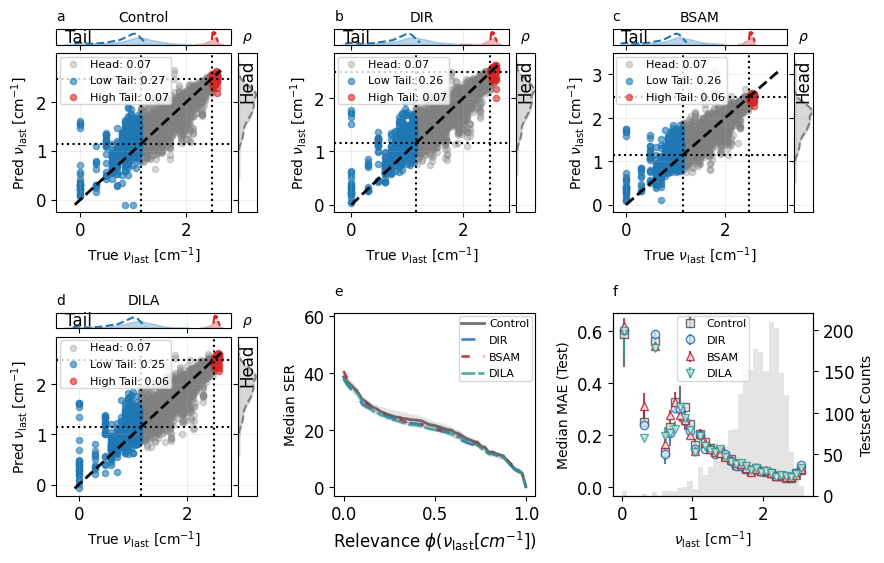


Analysing Fold 1
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.858)
    + Loaded NPZ Fallback Run 1 (R2: 0.854)
    + Loaded NPZ Fallback Run 2 (R2: 0.861)
    + Loaded NPZ Fallback Run 3 (R2: 0.860)
    + Loaded NPZ Fallback Run 4 (R2: 0.712)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.856)
    + Loaded NPZ Fallback Run 1 (R2: 0.850)
    + Loaded NPZ Fallback Run 2 (R2: 0.845)
    + Loaded NPZ Fallback Run 3 (R2: 0.850)
    + Loaded NPZ Fallback Run 4 (R2: 0.845)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.853)
    + Loaded NPZ Fallback Run 1 (R2: 0.853)
    + Loaded NPZ Fallback Run 2 (R2: 0.860)
    + Loaded NPZ Fallback Run 3 (R2: 0.858)
    + Loaded NPZ Fallback Run 4 (R2: 0.859)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.863)
    + Loaded NPZ Fallback Run 1 (R2: 0.863)
    + Loaded NPZ Fallback Run 2 (R2: 0.851)
    + Loaded NPZ Fallback Run 3 (R2: 0.860)
    + Loaded NPZ Fallback Run 4 (R2: 0.858)
--> Dropped expl

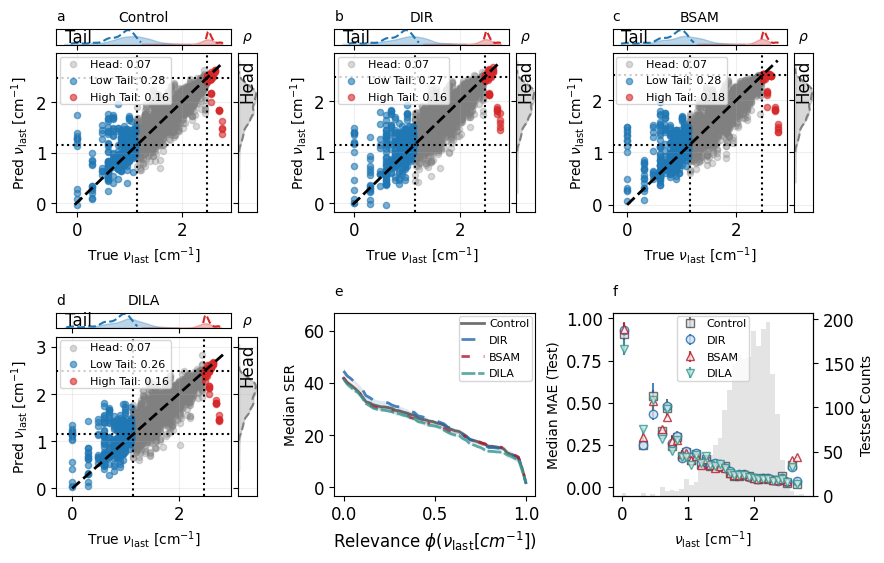


Analysing Fold 2
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.870)
    + Loaded NPZ Fallback Run 1 (R2: 0.874)
    + Loaded NPZ Fallback Run 2 (R2: 0.786)
    + Loaded NPZ Fallback Run 3 (R2: 0.870)
    + Loaded NPZ Fallback Run 4 (R2: 0.871)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.868)
    + Loaded NPZ Fallback Run 1 (R2: 0.867)
    + Loaded NPZ Fallback Run 2 (R2: 0.867)
    + Loaded NPZ Fallback Run 3 (R2: 0.858)
    + Loaded NPZ Fallback Run 4 (R2: 0.877)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.880)
    + Loaded NPZ Fallback Run 1 (R2: 0.865)
    + Loaded NPZ Fallback Run 2 (R2: 0.878)
    + Loaded NPZ Fallback Run 3 (R2: 0.856)
    + Loaded NPZ Fallback Run 4 (R2: 0.874)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.873)
    + Loaded NPZ Fallback Run 1 (R2: 0.872)
    + Loaded NPZ Fallback Run 2 (R2: 0.866)
    + Loaded NPZ Fallback Run 3 (R2: 0.854)
    + Loaded NPZ Fallback Run 4 (R2: 0.879)
--> Dropped expl

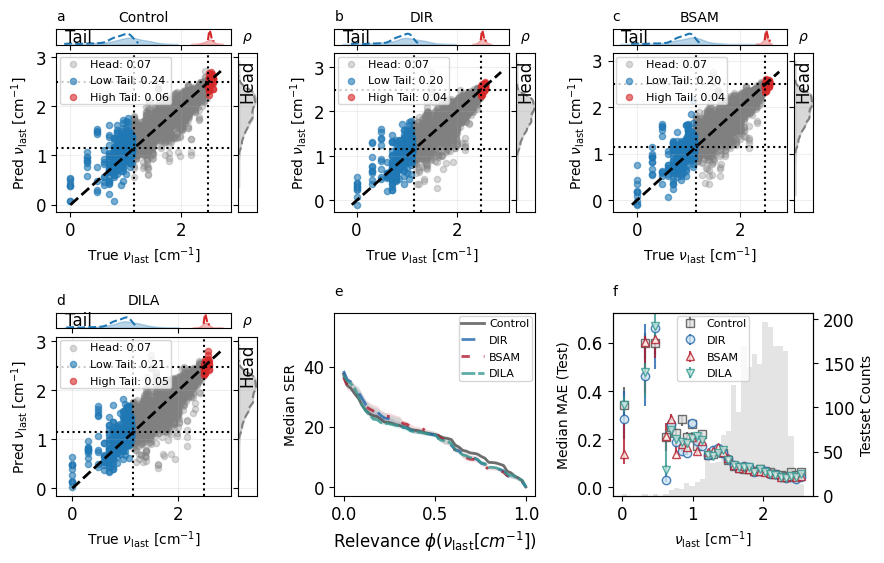


Analysing Fold 3
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.843)
    + Loaded NPZ Fallback Run 1 (R2: 0.851)
    + Loaded NPZ Fallback Run 2 (R2: 0.854)
    + Loaded NPZ Fallback Run 3 (R2: 0.830)
    + Loaded NPZ Fallback Run 4 (R2: 0.836)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.842)
    + Loaded NPZ Fallback Run 1 (R2: 0.840)
    + Loaded NPZ Fallback Run 2 (R2: 0.848)
    + Loaded NPZ Fallback Run 3 (R2: 0.833)
    + Loaded NPZ Fallback Run 4 (R2: 0.827)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.844)
    + Loaded NPZ Fallback Run 1 (R2: 0.845)
    + Loaded NPZ Fallback Run 2 (R2: 0.859)
    + Loaded NPZ Fallback Run 3 (R2: 0.844)
    + Loaded NPZ Fallback Run 4 (R2: 0.846)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.862)
    + Loaded NPZ Fallback Run 1 (R2: 0.844)
    + Loaded NPZ Fallback Run 2 (R2: 0.845)
    + Loaded NPZ Fallback Run 3 (R2: 0.843)
    + Loaded NPZ Fallback Run 4 (R2: 0.848)


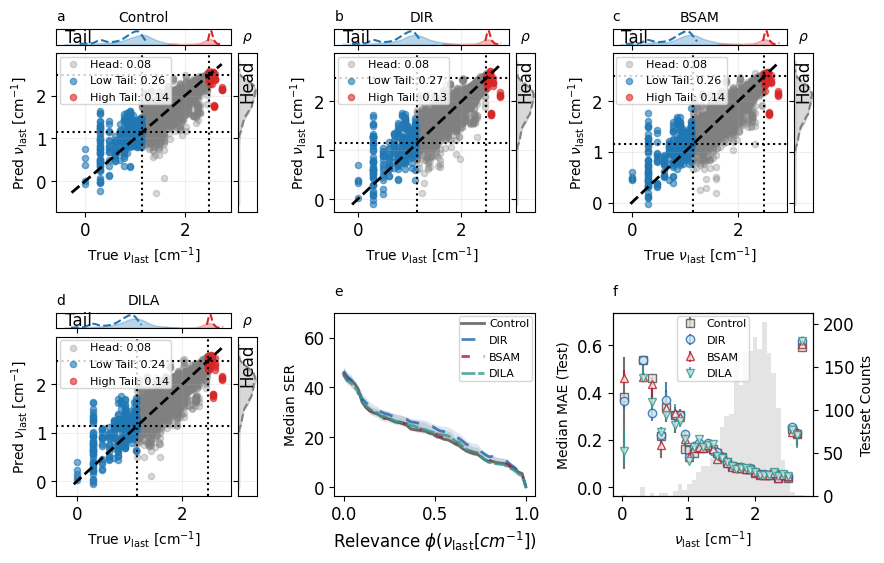


Analysing Fold 4
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.743)
    + Loaded NPZ Fallback Run 1 (R2: 0.764)
    + Loaded NPZ Fallback Run 2 (R2: 0.854)
    + Loaded NPZ Fallback Run 3 (R2: 0.858)
    + Loaded NPZ Fallback Run 4 (R2: 0.662)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.858)
    + Loaded NPZ Fallback Run 1 (R2: 0.848)
    + Loaded NPZ Fallback Run 2 (R2: 0.869)
    + Loaded NPZ Fallback Run 3 (R2: 0.856)
    + Loaded NPZ Fallback Run 4 (R2: 0.856)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.865)
    + Loaded NPZ Fallback Run 1 (R2: 0.855)
    + Loaded NPZ Fallback Run 2 (R2: 0.857)
    + Loaded NPZ Fallback Run 3 (R2: 0.851)
    + Loaded NPZ Fallback Run 4 (R2: 0.870)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.853)
    + Loaded NPZ Fallback Run 1 (R2: 0.853)
    + Loaded NPZ Fallback Run 2 (R2: 0.858)
    + Loaded NPZ Fallback Run 3 (R2: 0.869)
    + Loaded NPZ Fallback Run 4 (R2: 0.845)
--> Dropped expl

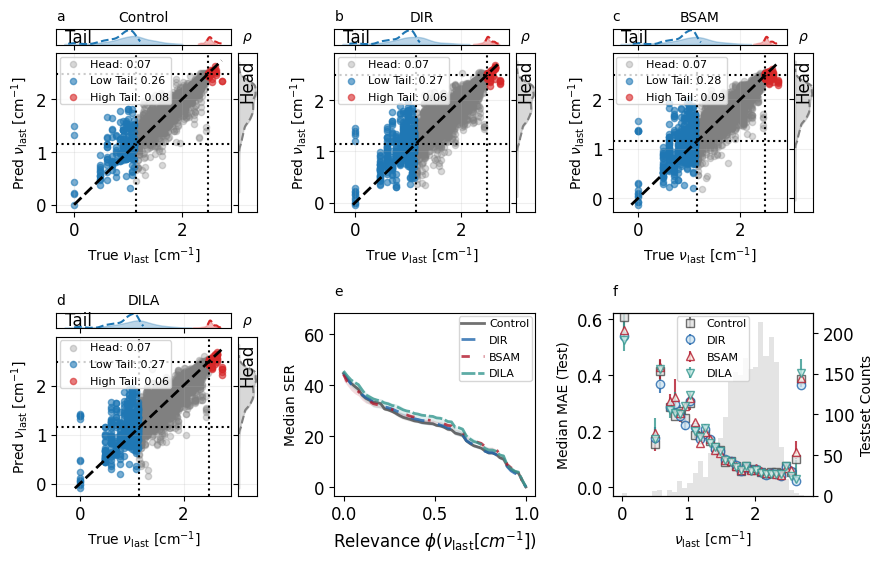


Analysing Fold 0
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.856)
    + Loaded NPZ Fallback Run 1 (R2: 0.827)
    + Loaded NPZ Fallback Run 2 (R2: 0.858)
    + Loaded NPZ Fallback Run 3 (R2: 0.851)
    + Loaded NPZ Fallback Run 4 (R2: 0.852)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.851)
    + Loaded NPZ Fallback Run 1 (R2: 0.840)
    + Loaded NPZ Fallback Run 2 (R2: 0.859)
    + Loaded NPZ Fallback Run 3 (R2: 0.846)
    + Loaded NPZ Fallback Run 4 (R2: 0.848)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.859)
    + Loaded NPZ Fallback Run 1 (R2: 0.857)
    + Loaded NPZ Fallback Run 2 (R2: 0.859)
    + Loaded NPZ Fallback Run 3 (R2: 0.854)
    + Loaded NPZ Fallback Run 4 (R2: 0.853)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.851)
    + Loaded NPZ Fallback Run 1 (R2: 0.780)
    + Loaded NPZ Fallback Run 2 (R2: 0.856)
    + Loaded NPZ Fallback Run 3 (R2: 0.850)
    + Loaded NPZ Fallback Run 4 (R2: 0.582)
--> Dropped expl

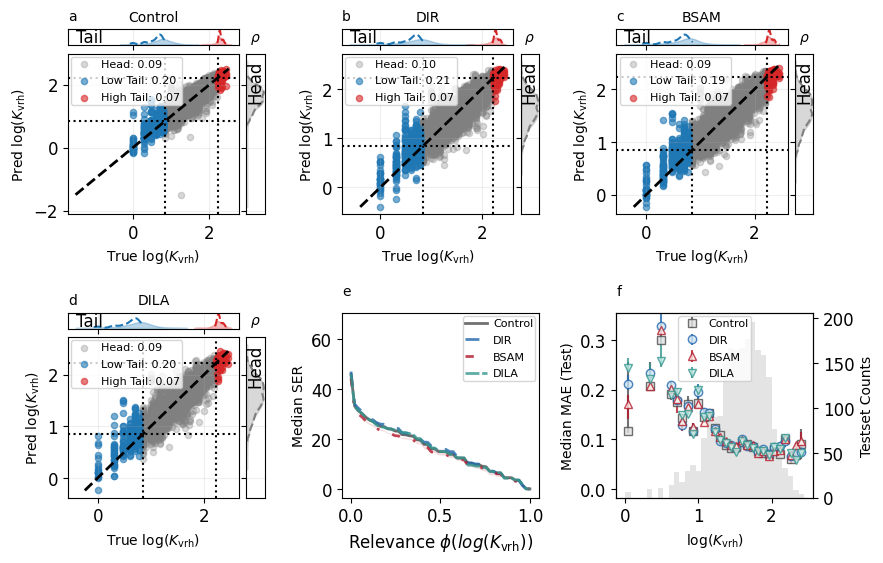


Analysing Fold 1
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.848)
    + Loaded NPZ Fallback Run 1 (R2: 0.716)
    + Loaded NPZ Fallback Run 2 (R2: 0.838)
    + Loaded NPZ Fallback Run 3 (R2: 0.845)
    + Loaded NPZ Fallback Run 4 (R2: 0.855)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.845)
    + Loaded NPZ Fallback Run 1 (R2: 0.842)
    + Loaded NPZ Fallback Run 2 (R2: 0.850)
    + Loaded NPZ Fallback Run 3 (R2: 0.831)
    + Loaded NPZ Fallback Run 4 (R2: 0.854)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.841)
    + Loaded NPZ Fallback Run 1 (R2: 0.844)
    + Loaded NPZ Fallback Run 2 (R2: 0.843)
    + Loaded NPZ Fallback Run 3 (R2: 0.833)
    + Loaded NPZ Fallback Run 4 (R2: 0.850)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.854)
    + Loaded NPZ Fallback Run 1 (R2: 0.843)
    + Loaded NPZ Fallback Run 2 (R2: 0.843)
    + Loaded NPZ Fallback Run 3 (R2: 0.851)
    + Loaded NPZ Fallback Run 4 (R2: 0.844)
--> Dropped expl

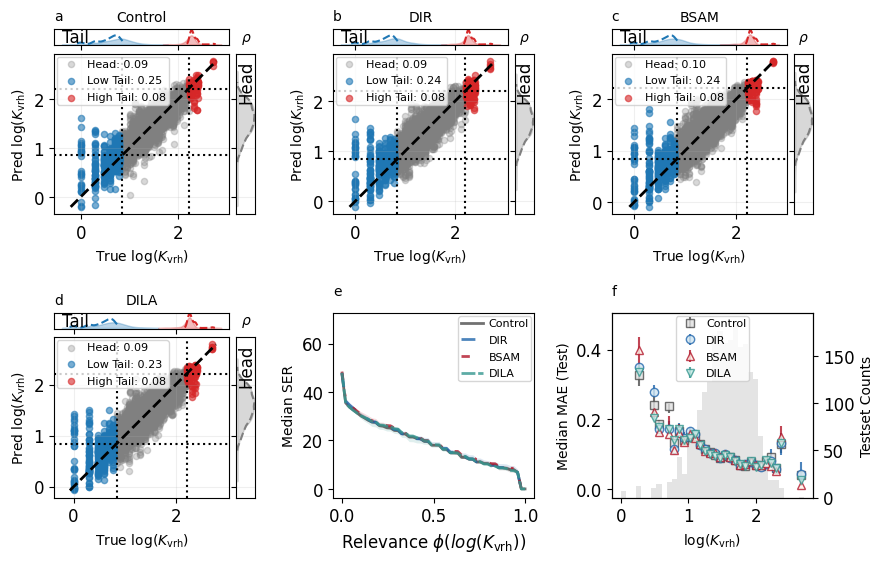


Analysing Fold 2
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.844)
    + Loaded NPZ Fallback Run 1 (R2: 0.835)
    + Loaded NPZ Fallback Run 2 (R2: 0.861)
    + Loaded NPZ Fallback Run 3 (R2: 0.844)
    + Loaded NPZ Fallback Run 4 (R2: 0.847)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.839)
    + Loaded NPZ Fallback Run 1 (R2: 0.837)
    + Loaded NPZ Fallback Run 2 (R2: 0.788)
    + Loaded NPZ Fallback Run 3 (R2: 0.852)
    + Loaded NPZ Fallback Run 4 (R2: 0.840)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.855)
    + Loaded NPZ Fallback Run 1 (R2: 0.851)
    + Loaded NPZ Fallback Run 2 (R2: 0.842)
    + Loaded NPZ Fallback Run 3 (R2: 0.845)
    + Loaded NPZ Fallback Run 4 (R2: 0.853)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.742)
    + Loaded NPZ Fallback Run 1 (R2: 0.845)
    + Loaded NPZ Fallback Run 2 (R2: 0.852)
    + Loaded NPZ Fallback Run 3 (R2: 0.848)
    + Loaded NPZ Fallback Run 4 (R2: -3.003)
--> Dropped exp

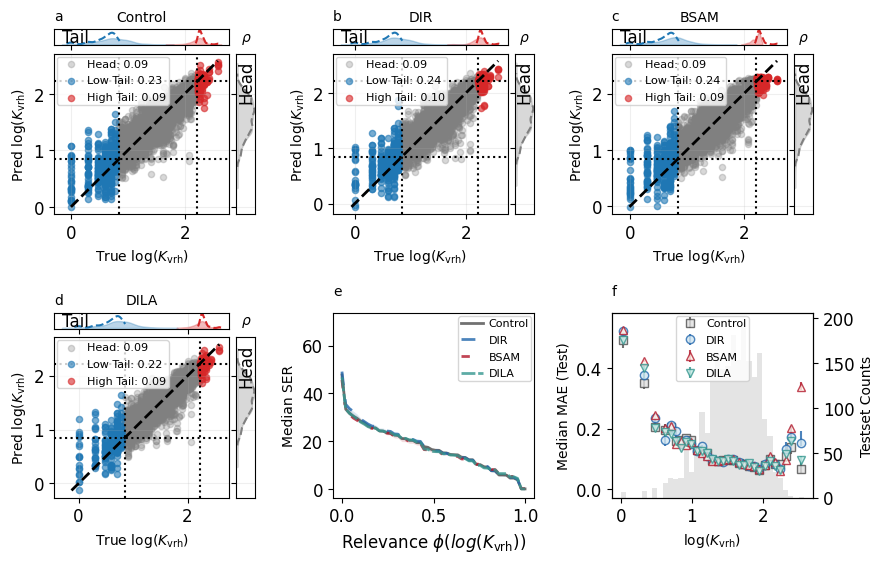


Analysing Fold 3
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.834)
    + Loaded NPZ Fallback Run 1 (R2: 0.835)
    + Loaded NPZ Fallback Run 2 (R2: 0.833)
    + Loaded NPZ Fallback Run 3 (R2: 0.832)
    + Loaded NPZ Fallback Run 4 (R2: 0.827)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.832)
    + Loaded NPZ Fallback Run 1 (R2: 0.827)
    + Loaded NPZ Fallback Run 2 (R2: 0.829)
    + Loaded NPZ Fallback Run 3 (R2: 0.821)
    + Loaded NPZ Fallback Run 4 (R2: 0.830)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.832)
    + Loaded NPZ Fallback Run 1 (R2: 0.840)
    + Loaded NPZ Fallback Run 2 (R2: 0.829)
    + Loaded NPZ Fallback Run 3 (R2: 0.827)
    + Loaded NPZ Fallback Run 4 (R2: 0.831)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.819)
    + Loaded NPZ Fallback Run 1 (R2: 0.818)
    + Loaded NPZ Fallback Run 2 (R2: -8.453)
    + Loaded NPZ Fallback Run 3 (R2: 0.826)
    + Loaded NPZ Fallback Run 4 (R2: 0.830)
--> Dropped exp

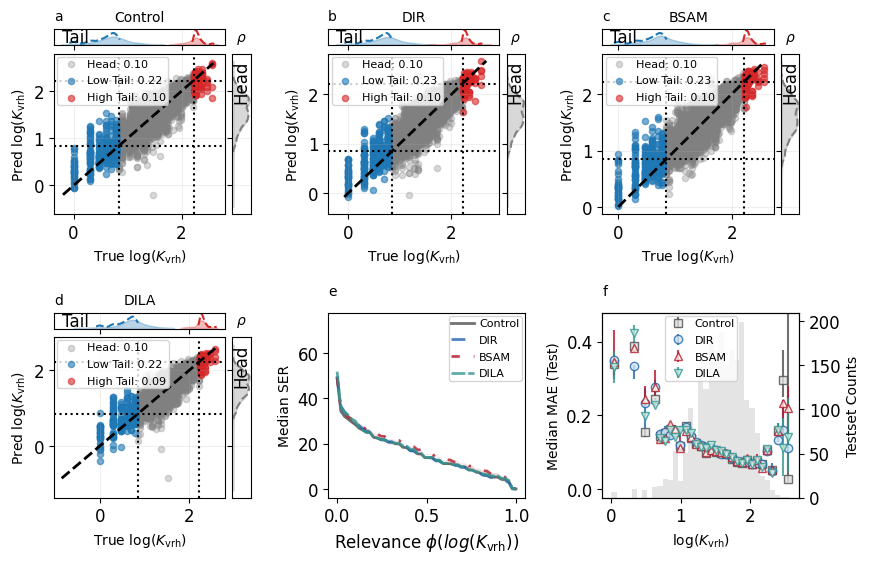


Analysing Fold 4
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.844)
    + Loaded NPZ Fallback Run 1 (R2: 0.838)
    + Loaded NPZ Fallback Run 2 (R2: 0.852)
    + Loaded NPZ Fallback Run 3 (R2: 0.833)
    + Loaded NPZ Fallback Run 4 (R2: 0.850)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.837)
    + Loaded NPZ Fallback Run 1 (R2: 0.844)
    + Loaded NPZ Fallback Run 2 (R2: 0.833)
    + Loaded NPZ Fallback Run 3 (R2: 0.836)
    + Loaded NPZ Fallback Run 4 (R2: 0.853)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.848)
    + Loaded NPZ Fallback Run 1 (R2: 0.862)
    + Loaded NPZ Fallback Run 2 (R2: 0.857)
    + Loaded NPZ Fallback Run 3 (R2: 0.856)
    + Loaded NPZ Fallback Run 4 (R2: 0.848)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.826)
    + Loaded NPZ Fallback Run 1 (R2: 0.826)
    + Loaded NPZ Fallback Run 2 (R2: 0.795)
    + Loaded NPZ Fallback Run 3 (R2: 0.806)
    + Loaded NPZ Fallback Run 4 (R2: 0.843)


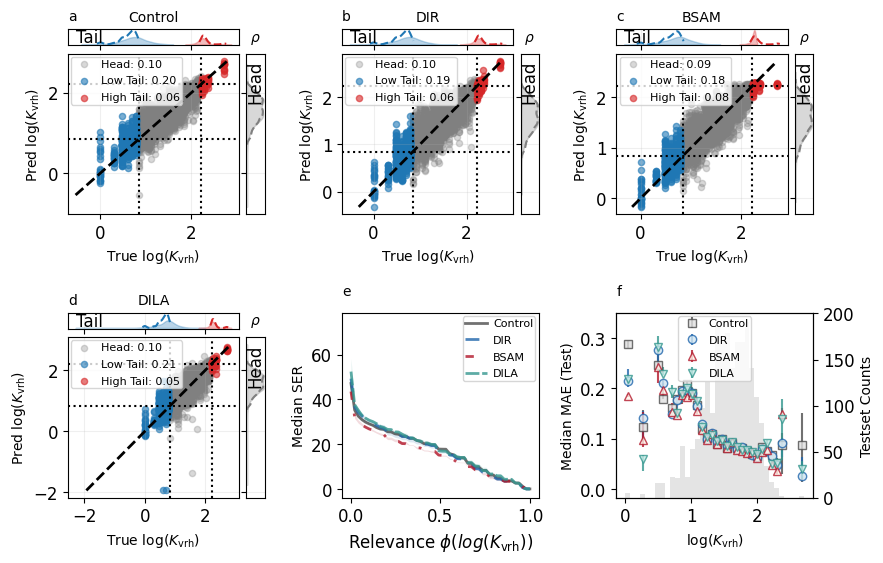


Analysing Fold 0
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.991)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.991)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.991)
    + Loaded NPZ Fallback Run 2 (R2: 0.991)
    + Loaded NPZ Fallback Run 3 (R2: 0.991)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.991)
    + Loaded NPZ Fallback Run 2 (R2: 0.991)
    + Loaded NPZ Fallback Run 3 (R2: 0.991)
    + Loaded NPZ Fallback Run 4 (R2: 0.990)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.991)
    + Loaded NPZ Fallback Run 1 (R2: 0.990)
    + Loaded NPZ Fallback Run 2 (R2: 0.991)
    + Loaded NPZ Fallback Run 3 (R2: 0.991)
    + Loaded NPZ Fallback Run 4 (R2: 0.992)


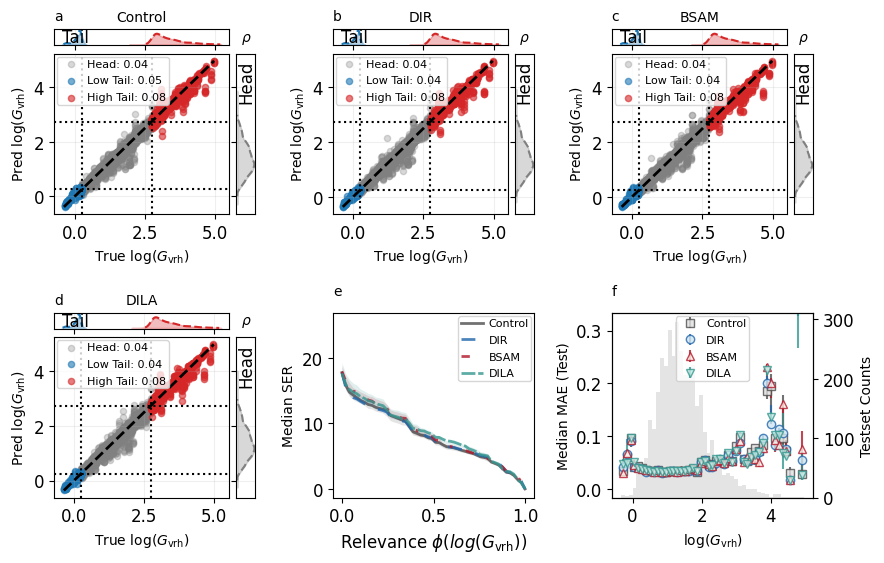


Analysing Fold 1
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.990)
    + Loaded NPZ Fallback Run 1 (R2: 0.991)
    + Loaded NPZ Fallback Run 2 (R2: 0.991)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.991)
    + Loaded NPZ Fallback Run 1 (R2: 0.991)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.990)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.990)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.991)
    + Loaded NPZ Fallback Run 1 (R2: 0.990)
    + Loaded NPZ Fallback Run 2 (R2: 0.991)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)


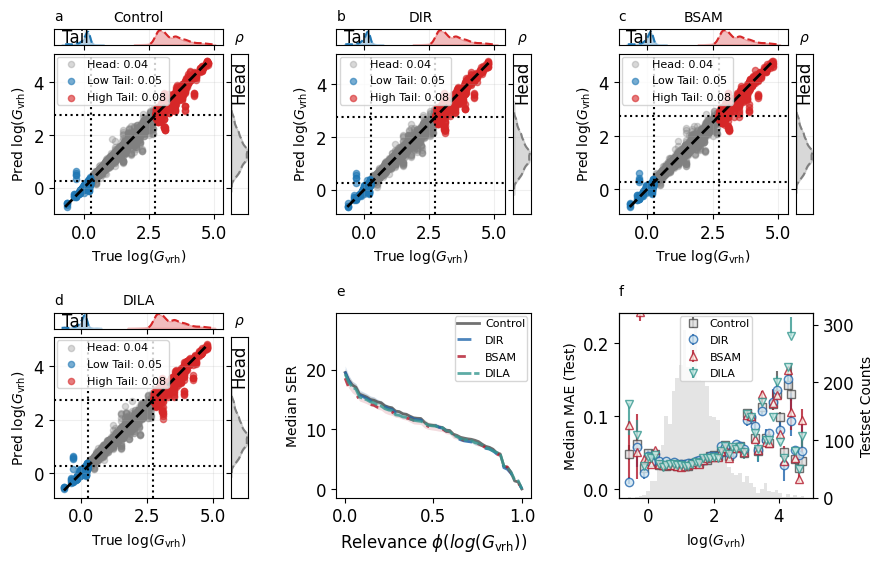


Analysing Fold 2
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.993)
    + Loaded NPZ Fallback Run 1 (R2: 0.993)
    + Loaded NPZ Fallback Run 2 (R2: 0.993)
    + Loaded NPZ Fallback Run 3 (R2: 0.993)
    + Loaded NPZ Fallback Run 4 (R2: 0.994)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.993)
    + Loaded NPZ Fallback Run 1 (R2: 0.993)
    + Loaded NPZ Fallback Run 2 (R2: 0.994)
    + Loaded NPZ Fallback Run 3 (R2: 0.994)
    + Loaded NPZ Fallback Run 4 (R2: 0.993)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.993)
    + Loaded NPZ Fallback Run 1 (R2: 0.994)
    + Loaded NPZ Fallback Run 2 (R2: 0.993)
    + Loaded NPZ Fallback Run 3 (R2: 0.993)
    + Loaded NPZ Fallback Run 4 (R2: 0.993)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.993)
    + Loaded NPZ Fallback Run 1 (R2: 0.993)
    + Loaded NPZ Fallback Run 2 (R2: 0.993)
    + Loaded NPZ Fallback Run 3 (R2: 0.994)
    + Loaded NPZ Fallback Run 4 (R2: 0.993)


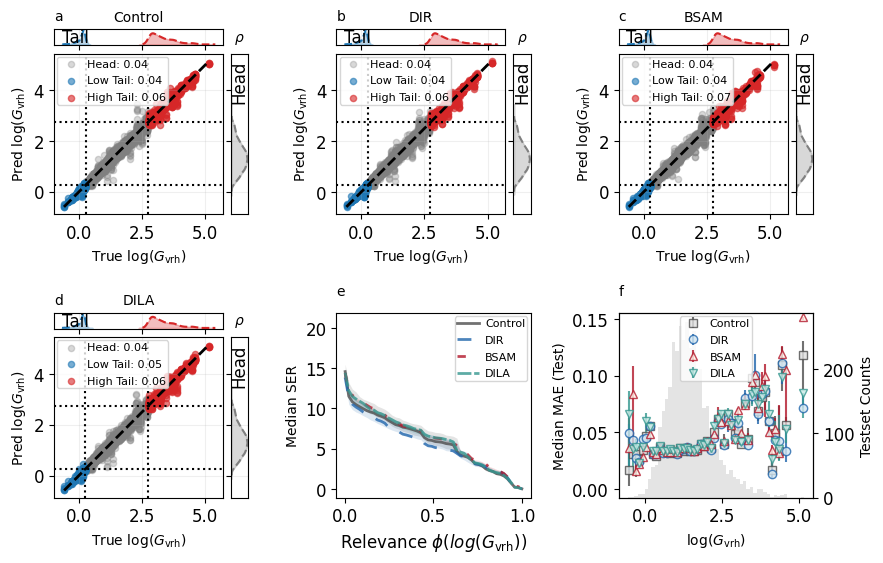


Analysing Fold 3
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.992)
    + Loaded NPZ Fallback Run 2 (R2: 0.993)
    + Loaded NPZ Fallback Run 3 (R2: 0.993)
    + Loaded NPZ Fallback Run 4 (R2: 0.992)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.993)
    + Loaded NPZ Fallback Run 1 (R2: 0.992)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.992)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.992)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.991)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.993)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.993)
    + Loaded NPZ Fallback Run 4 (R2: 0.993)


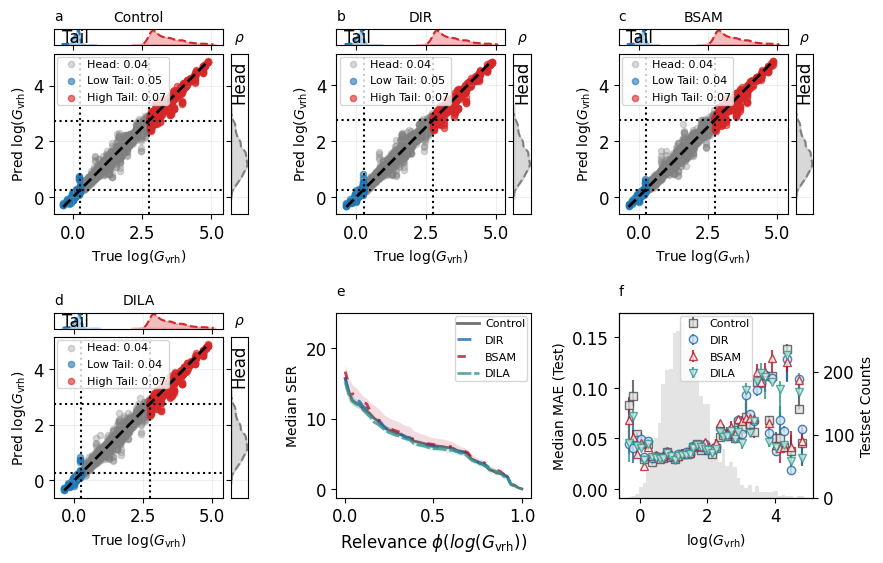


Analysing Fold 4
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.992)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.992)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.992)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.992)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.991)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.992)
    + Loaded NPZ Fallback Run 1 (R2: 0.992)
    + Loaded NPZ Fallback Run 2 (R2: 0.992)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.992)


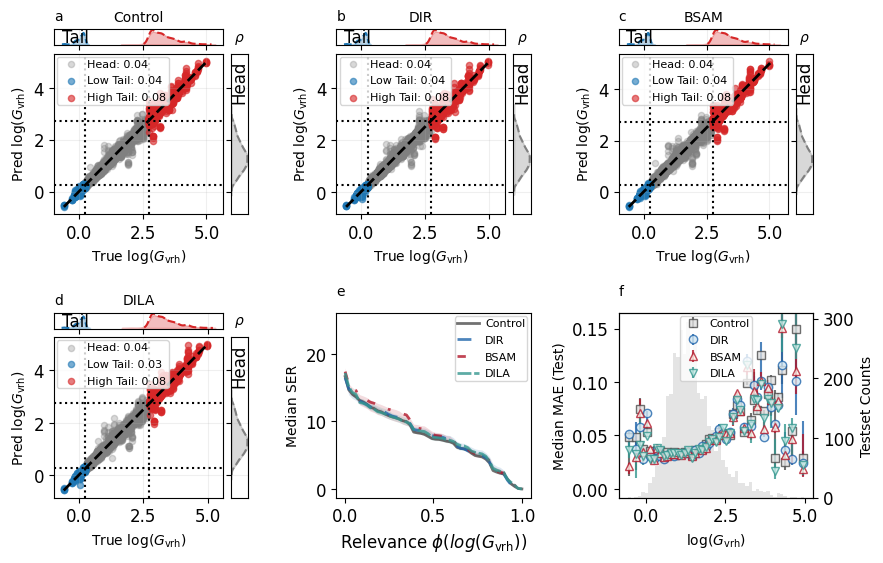


Analysing Fold 0
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.988)
    + Loaded NPZ Fallback Run 1 (R2: 0.989)
    + Loaded NPZ Fallback Run 2 (R2: 0.990)
    + Loaded NPZ Fallback Run 3 (R2: 0.988)
    + Loaded NPZ Fallback Run 4 (R2: 0.983)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.988)
    + Loaded NPZ Fallback Run 1 (R2: 0.989)
    + Loaded NPZ Fallback Run 2 (R2: 0.987)
    + Loaded NPZ Fallback Run 3 (R2: 0.982)
    + Loaded NPZ Fallback Run 4 (R2: 0.984)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.991)
    + Loaded NPZ Fallback Run 1 (R2: 0.990)
    + Loaded NPZ Fallback Run 2 (R2: 0.989)
    + Loaded NPZ Fallback Run 3 (R2: 0.898)
    + Loaded NPZ Fallback Run 4 (R2: 0.984)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.986)
    + Loaded NPZ Fallback Run 1 (R2: 0.991)
    + Loaded NPZ Fallback Run 2 (R2: 0.990)
    + Loaded NPZ Fallback Run 3 (R2: 0.990)
    + Loaded NPZ Fallback Run 4 (R2: 0.985)
--> Dropped expl

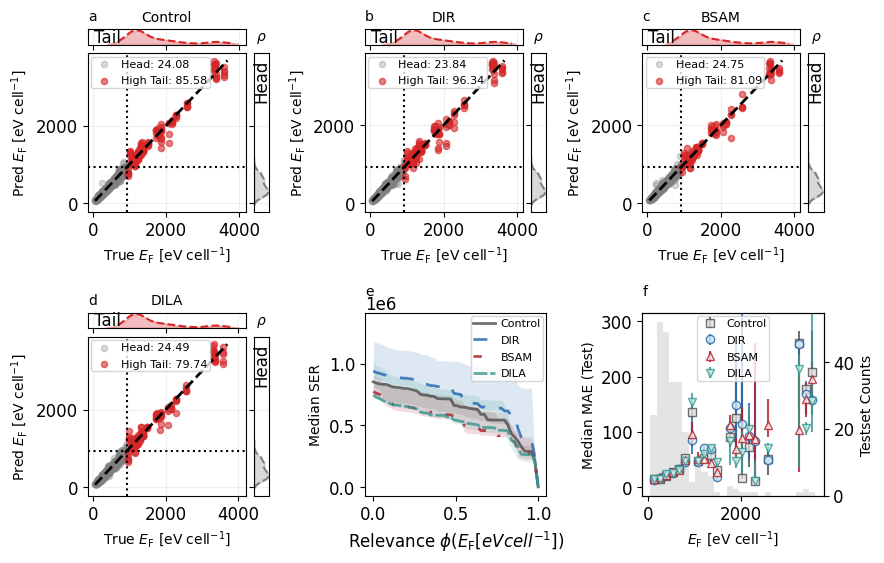


Analysing Fold 1
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.986)
    + Loaded NPZ Fallback Run 1 (R2: 0.984)
    + Loaded NPZ Fallback Run 2 (R2: 0.981)
    + Loaded NPZ Fallback Run 3 (R2: 0.983)
    + Loaded NPZ Fallback Run 4 (R2: 0.977)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.983)
    + Loaded NPZ Fallback Run 1 (R2: 0.982)
    + Loaded NPZ Fallback Run 2 (R2: 0.982)
    + Loaded NPZ Fallback Run 3 (R2: 0.983)
    + Loaded NPZ Fallback Run 4 (R2: 0.985)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.976)
    + Loaded NPZ Fallback Run 1 (R2: 0.986)
    + Loaded NPZ Fallback Run 2 (R2: 0.983)
    + Loaded NPZ Fallback Run 3 (R2: 0.985)
    + Loaded NPZ Fallback Run 4 (R2: 0.978)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.977)
    + Loaded NPZ Fallback Run 1 (R2: 0.982)
    + Loaded NPZ Fallback Run 2 (R2: 0.984)
    + Loaded NPZ Fallback Run 3 (R2: 0.983)
    + Loaded NPZ Fallback Run 4 (R2: 0.982)


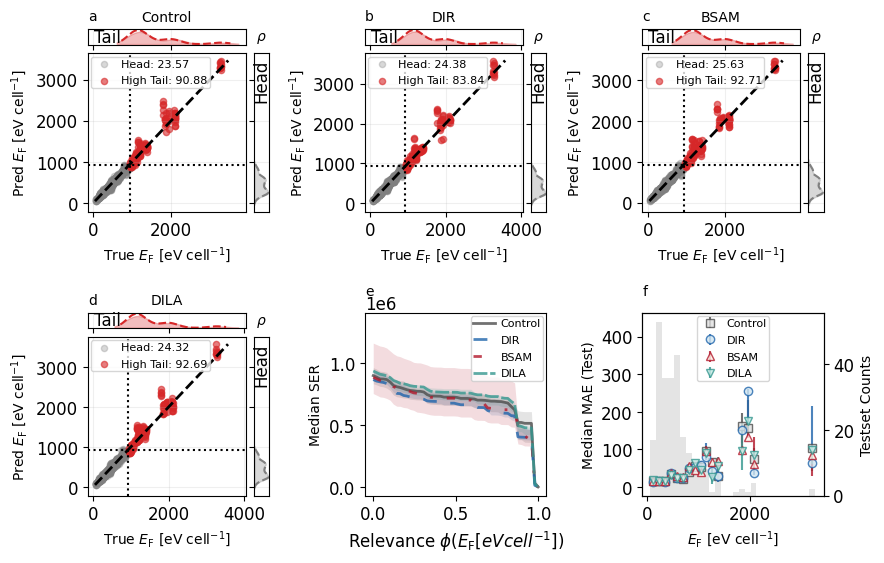


Analysing Fold 2
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.989)
    + Loaded NPZ Fallback Run 1 (R2: 0.985)
    + Loaded NPZ Fallback Run 2 (R2: 0.984)
    + Loaded NPZ Fallback Run 3 (R2: 0.989)
    + Loaded NPZ Fallback Run 4 (R2: 0.989)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.993)
    + Loaded NPZ Fallback Run 1 (R2: 0.989)
    + Loaded NPZ Fallback Run 2 (R2: 0.988)
    + Loaded NPZ Fallback Run 3 (R2: 0.988)
    + Loaded NPZ Fallback Run 4 (R2: 0.991)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.990)
    + Loaded NPZ Fallback Run 1 (R2: 0.989)
    + Loaded NPZ Fallback Run 2 (R2: 0.978)
    + Loaded NPZ Fallback Run 3 (R2: 0.983)
    + Loaded NPZ Fallback Run 4 (R2: 0.987)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.985)
    + Loaded NPZ Fallback Run 1 (R2: 0.985)
    + Loaded NPZ Fallback Run 2 (R2: 0.979)
    + Loaded NPZ Fallback Run 3 (R2: 0.987)
    + Loaded NPZ Fallback Run 4 (R2: 0.987)


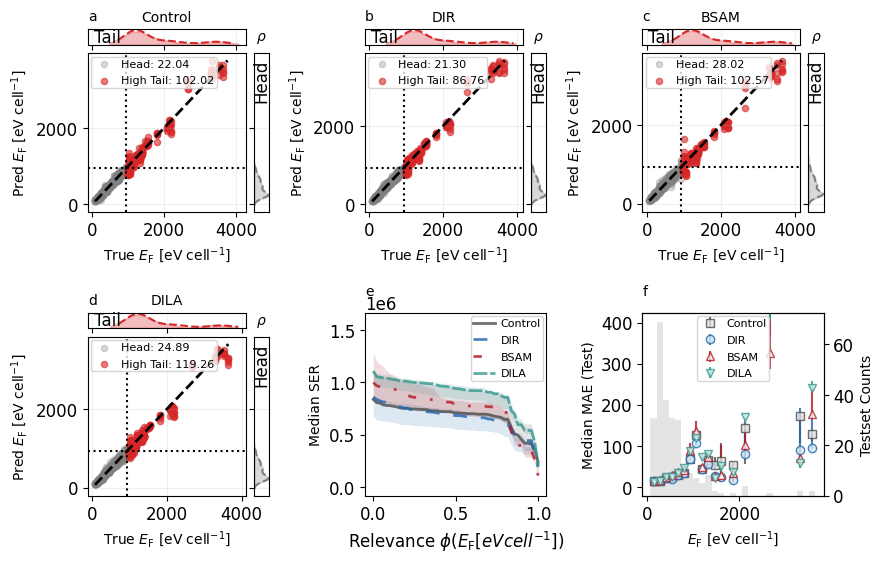


Analysing Fold 3
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.980)
    + Loaded NPZ Fallback Run 1 (R2: 0.975)
    + Loaded NPZ Fallback Run 2 (R2: 0.972)
    + Loaded NPZ Fallback Run 3 (R2: 0.982)
    + Loaded NPZ Fallback Run 4 (R2: 0.974)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.989)
    + Loaded NPZ Fallback Run 1 (R2: 0.983)
    + Loaded NPZ Fallback Run 2 (R2: 0.980)
    + Loaded NPZ Fallback Run 3 (R2: 0.978)
    + Loaded NPZ Fallback Run 4 (R2: 0.980)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.976)
    + Loaded NPZ Fallback Run 1 (R2: 0.979)
    + Loaded NPZ Fallback Run 2 (R2: 0.984)
    + Loaded NPZ Fallback Run 3 (R2: 0.992)
    + Loaded NPZ Fallback Run 4 (R2: 0.987)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.971)
    + Loaded NPZ Fallback Run 1 (R2: 0.981)
    + Loaded NPZ Fallback Run 2 (R2: 0.976)
    + Loaded NPZ Fallback Run 3 (R2: 0.980)
    + Loaded NPZ Fallback Run 4 (R2: 0.979)


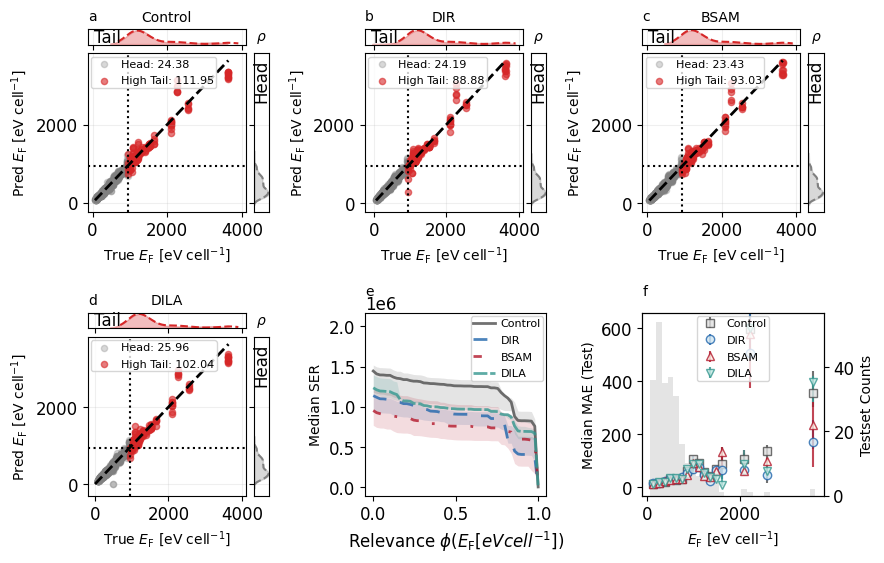


Analysing Fold 4
  Evaluating Control...
    + Loaded NPZ Fallback Run 0 (R2: 0.984)
    + Loaded NPZ Fallback Run 1 (R2: 0.979)
    + Loaded NPZ Fallback Run 2 (R2: 0.986)
    + Loaded NPZ Fallback Run 3 (R2: 0.987)
    + Loaded NPZ Fallback Run 4 (R2: 0.986)
  Evaluating DIR...
    + Loaded NPZ Fallback Run 0 (R2: 0.984)
    + Loaded NPZ Fallback Run 1 (R2: 0.983)
    + Loaded NPZ Fallback Run 2 (R2: 0.988)
    + Loaded NPZ Fallback Run 3 (R2: 0.988)
    + Loaded NPZ Fallback Run 4 (R2: 0.987)
  Evaluating BSAM...
    + Loaded NPZ Fallback Run 0 (R2: 0.974)
    + Loaded NPZ Fallback Run 1 (R2: 0.977)
    + Loaded NPZ Fallback Run 2 (R2: 0.982)
    + Loaded NPZ Fallback Run 3 (R2: 0.978)
    + Loaded NPZ Fallback Run 4 (R2: 0.979)
  Evaluating DILA...
    + Loaded NPZ Fallback Run 0 (R2: 0.982)
    + Loaded NPZ Fallback Run 1 (R2: 0.976)
    + Loaded NPZ Fallback Run 2 (R2: 0.985)
    + Loaded NPZ Fallback Run 3 (R2: 0.986)
    + Loaded NPZ Fallback Run 4 (R2: 0.988)


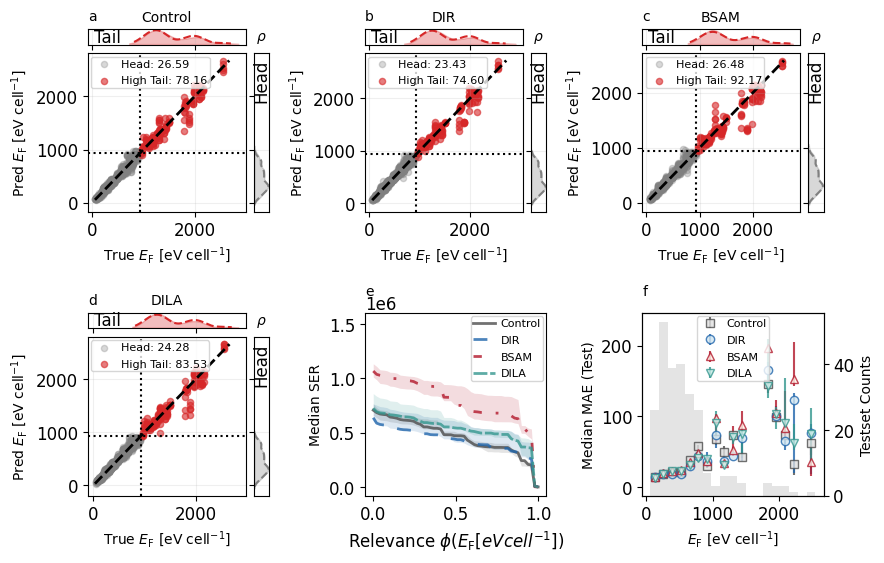

In [14]:
base_dir = "experiments/final"
datasets = ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']
math_names = [ r"log($K_{\mathrm{{vrh}}}$)", r"log($G_{\mathrm{{vrh}}}$)", r"$E_{\mathrm{{F}}}$ [eV cell$^{-1}$]", r"$\nu _{\mathrm{{last}}}$ [cm$^{-1}$]"]

for dataset, math_name in zip(datasets, math_names):
    globals()[f"{dataset}_analysers"], globals()[f"{dataset}_results"] = analyse_dataset(
        dataset, target_name = math_name, configs_dir='expt_configs/final',
        results_dir='experiments/final'
    )

In [5]:
all_dataset_analysers = {}

for dataset in ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']:
    all_dataset_analysers[dataset] = globals()[f"{dataset}_analysers"]

# Generate the LaTeX table all at once
generate_comprehensive_metrics_table(all_dataset_analysers, table_name='comprehensive_metrics_table.txt')


Analysing Metrics for: log_kvrh
--> Dropped exploded run from ensemble: R2=0.712 (Ensemble Best=0.861)
--> Dropped exploded run from ensemble: R2=0.786 (Ensemble Best=0.874)
--> Dropped exploded run from ensemble: R2=0.743 (Ensemble Best=0.858)
--> Dropped exploded run from ensemble: R2=0.764 (Ensemble Best=0.858)
--> Dropped exploded run from ensemble: R2=0.662 (Ensemble Best=0.858)

Analysing Metrics for: log_gvrh
--> Dropped exploded run from ensemble: R2=0.716 (Ensemble Best=0.855)
--> Dropped exploded run from ensemble: R2=0.788 (Ensemble Best=0.852)
--> Dropped exploded run from ensemble: R2=0.780 (Ensemble Best=0.856)
--> Dropped exploded run from ensemble: R2=0.582 (Ensemble Best=0.856)
--> Dropped exploded run from ensemble: R2=0.742 (Ensemble Best=0.852)
--> Dropped exploded run from ensemble: R2=-3.003 (Ensemble Best=0.852)
--> Dropped exploded run from ensemble: R2=-8.453 (Ensemble Best=0.830)

Analysing Metrics for: perovskites

Analysing Metrics for: phonons
--> Dropped 

#### MatFold


Analysing Fold 0
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.991)
    + Loaded CSV Run 1 (R2: 0.989)
    + Loaded CSV Run 2 (R2: 0.972)
    + Loaded CSV Run 3 (R2: 0.989)
    + Loaded CSV Run 4 (R2: 0.975)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.993)
    + Loaded CSV Run 1 (R2: 0.987)
    + Loaded CSV Run 2 (R2: 0.976)
    + Loaded CSV Run 3 (R2: 0.988)
    + Loaded CSV Run 4 (R2: 0.992)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.987)
    + Loaded CSV Run 1 (R2: 0.977)
    + Loaded CSV Run 2 (R2: 0.986)
    + Loaded CSV Run 3 (R2: 0.977)
    + Loaded CSV Run 4 (R2: 0.994)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.990)
    + Loaded CSV Run 1 (R2: 0.986)
    + Loaded CSV Run 2 (R2: 0.976)
    + Loaded CSV Run 3 (R2: 0.991)
    + Loaded CSV Run 4 (R2: 0.973)


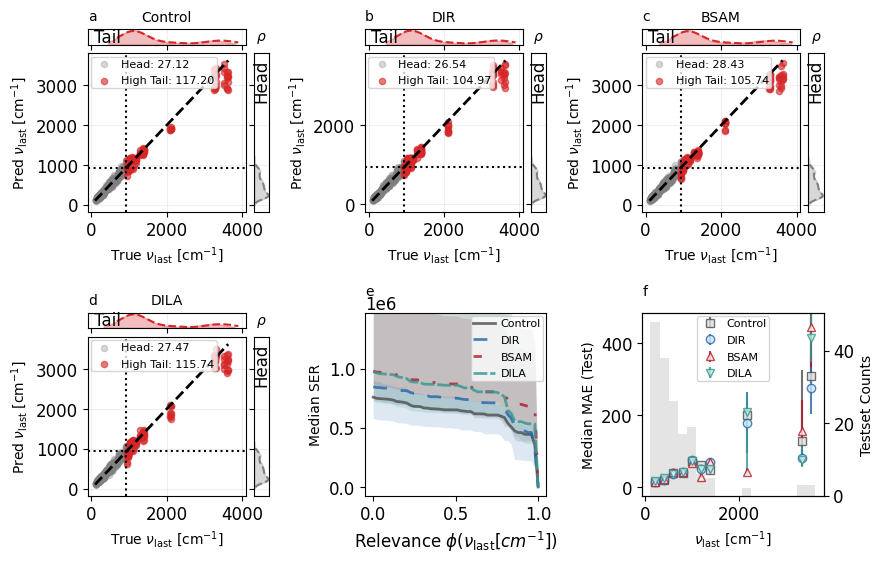


Analysing Fold 1
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.982)
    + Loaded CSV Run 1 (R2: 0.976)
    + Loaded CSV Run 2 (R2: 0.979)
    + Loaded CSV Run 3 (R2: 0.986)
    + Loaded CSV Run 4 (R2: 0.982)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.988)
    + Loaded CSV Run 1 (R2: 0.986)
    + Loaded CSV Run 2 (R2: 0.983)
    + Loaded CSV Run 3 (R2: 0.986)
    + Loaded CSV Run 4 (R2: 0.980)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.990)
    + Loaded CSV Run 1 (R2: 0.980)
    + Loaded CSV Run 2 (R2: 0.984)
    + Loaded CSV Run 3 (R2: 0.986)
    + Loaded CSV Run 4 (R2: 0.985)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.981)
    + Loaded CSV Run 1 (R2: 0.983)
    + Loaded CSV Run 2 (R2: 0.981)
    + Loaded CSV Run 3 (R2: 0.983)
    + Loaded CSV Run 4 (R2: 0.985)


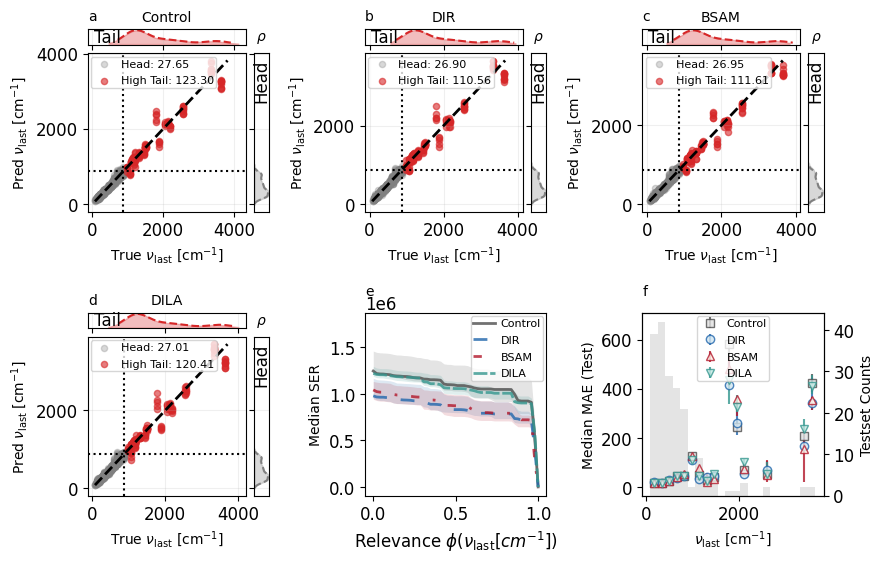


Analysing Fold 2
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.974)
    + Loaded CSV Run 1 (R2: 0.984)
    + Loaded CSV Run 2 (R2: 0.982)
    + Loaded CSV Run 3 (R2: 0.972)
    + Loaded CSV Run 4 (R2: 0.976)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.975)
    + Loaded CSV Run 1 (R2: 0.982)
    + Loaded CSV Run 2 (R2: 0.973)
    + Loaded CSV Run 3 (R2: 0.974)
    + Loaded CSV Run 4 (R2: 0.968)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.975)
    + Loaded CSV Run 1 (R2: 0.933)
    + Loaded CSV Run 2 (R2: 0.970)
    + Loaded CSV Run 3 (R2: 0.954)
    + Loaded CSV Run 4 (R2: 0.967)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: -8.346)
    + Loaded CSV Run 1 (R2: 0.978)
    + Loaded CSV Run 2 (R2: 0.984)
    + Loaded CSV Run 3 (R2: 0.974)
    + Loaded CSV Run 4 (R2: -78051.788)
--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-78051.788 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2

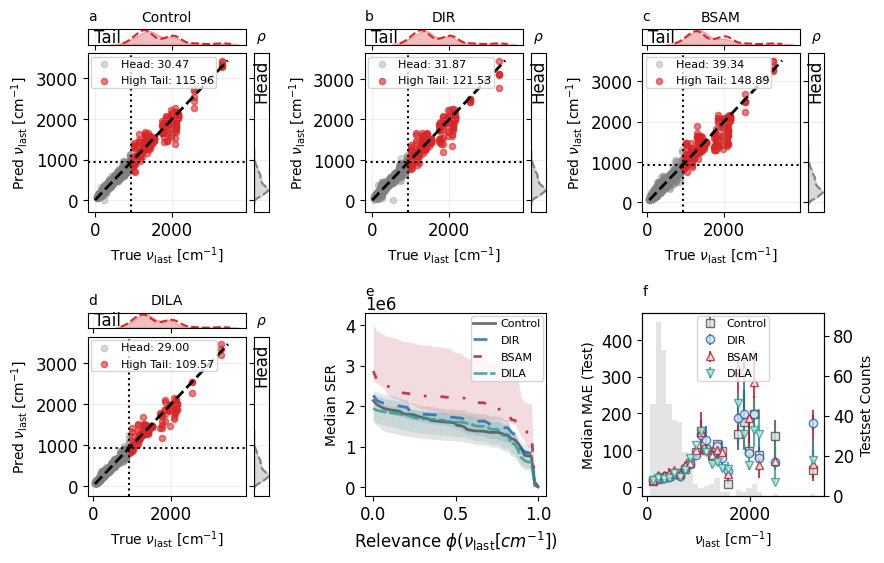


Analysing Fold 3
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.972)
    + Loaded CSV Run 1 (R2: 0.978)
    + Loaded CSV Run 2 (R2: 0.964)
    + Loaded CSV Run 3 (R2: 0.964)
    + Loaded CSV Run 4 (R2: 0.971)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.980)
    + Loaded CSV Run 1 (R2: 0.970)
    + Loaded CSV Run 2 (R2: 0.980)
    + Loaded CSV Run 3 (R2: 0.975)
    + Loaded CSV Run 4 (R2: 0.977)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.960)
    + Loaded CSV Run 1 (R2: 0.969)
    + Loaded CSV Run 2 (R2: 0.983)
    + Loaded CSV Run 3 (R2: 0.951)
    + Loaded CSV Run 4 (R2: 0.968)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.962)
    + Loaded CSV Run 1 (R2: 0.963)
    + Loaded CSV Run 2 (R2: 0.973)
    + Loaded CSV Run 3 (R2: 0.975)
    + Loaded CSV Run 4 (R2: 0.983)


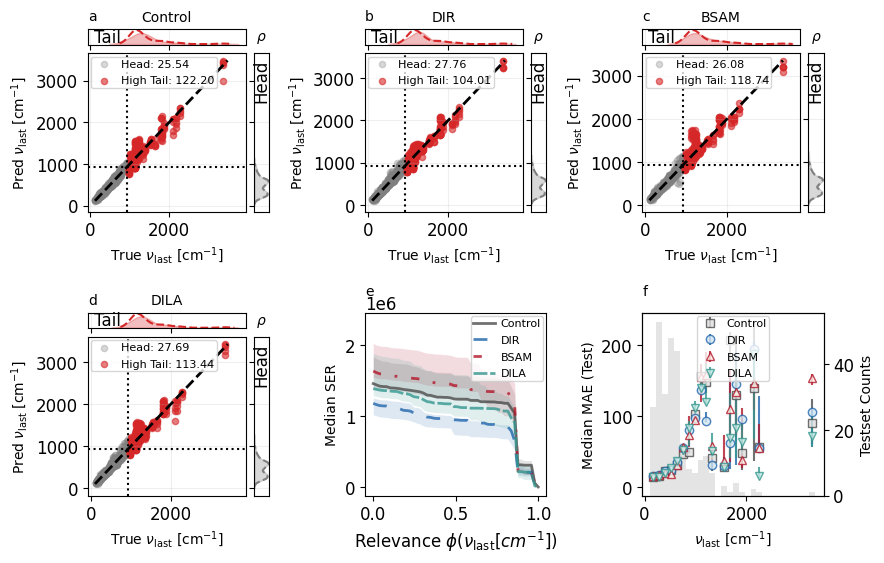


Analysing Fold 4
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.924)
    + Loaded CSV Run 1 (R2: 0.951)
    + Loaded CSV Run 2 (R2: 0.943)
    + Loaded CSV Run 3 (R2: 0.946)
    + Loaded CSV Run 4 (R2: 0.949)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.936)
    + Loaded CSV Run 1 (R2: 0.920)
    + Loaded CSV Run 2 (R2: 0.936)
    + Loaded CSV Run 3 (R2: 0.945)
    + Loaded CSV Run 4 (R2: 0.918)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.913)
    + Loaded CSV Run 1 (R2: 0.921)
    + Loaded CSV Run 2 (R2: 0.896)
    + Loaded CSV Run 3 (R2: 0.926)
    + Loaded CSV Run 4 (R2: 0.899)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.925)
    + Loaded CSV Run 1 (R2: 0.947)
    + Loaded CSV Run 2 (R2: 0.936)
    + Loaded CSV Run 3 (R2: 0.931)
    + Loaded CSV Run 4 (R2: 0.920)


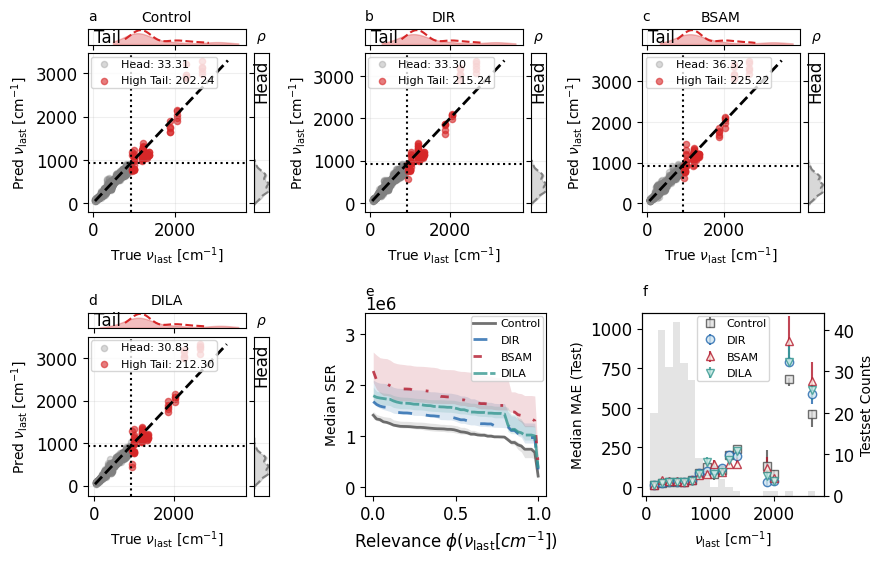


Analysing Fold 0
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.835)
    + Loaded CSV Run 1 (R2: 0.807)
    + Loaded CSV Run 2 (R2: 0.824)
    + Loaded CSV Run 3 (R2: 0.828)
    + Loaded CSV Run 4 (R2: 0.821)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.820)
    + Loaded CSV Run 1 (R2: 0.814)
    + Loaded CSV Run 2 (R2: 0.674)
    + Loaded CSV Run 3 (R2: 0.827)
    + Loaded CSV Run 4 (R2: 0.828)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.825)
    + Loaded CSV Run 1 (R2: 0.797)
    + Loaded CSV Run 2 (R2: 0.827)
    + Loaded CSV Run 3 (R2: 0.822)
    + Loaded CSV Run 4 (R2: 0.821)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.836)
    + Loaded CSV Run 1 (R2: 0.824)
    + Loaded CSV Run 2 (R2: 0.834)
    + Loaded CSV Run 3 (R2: 0.825)
    + Loaded CSV Run 4 (R2: 0.826)
--> Dropped exploded run from ensemble: R2=0.674 (Ensemble Best=0.828)
--> Dropped exploded run from ensemble: R2=0.674 (Ensemble Best=0.828)
--> Dropped exploded run from ensemble: R2=0.674 (Ense

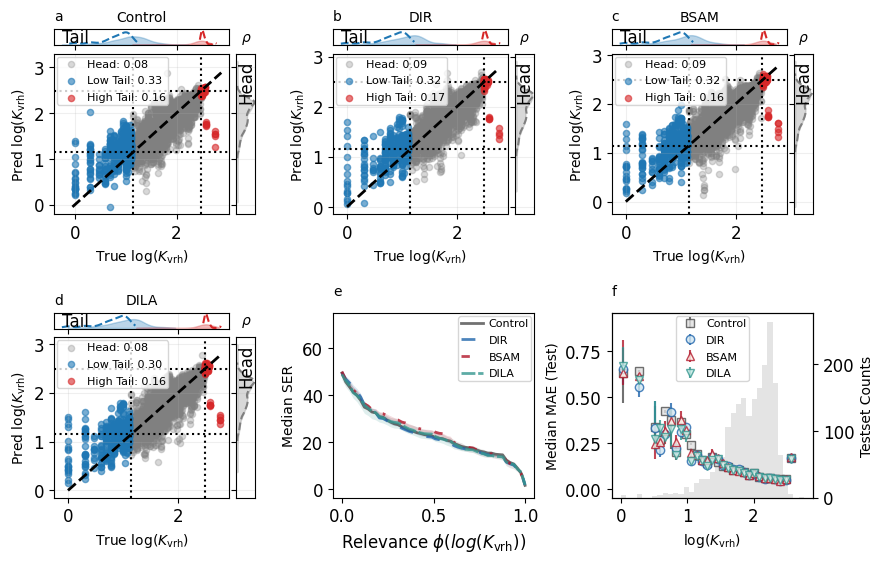


Analysing Fold 1
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.803)
    + Loaded CSV Run 1 (R2: 0.823)
    + Loaded CSV Run 2 (R2: 0.823)
    + Loaded CSV Run 3 (R2: 0.812)
    + Loaded CSV Run 4 (R2: 0.830)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.831)
    + Loaded CSV Run 1 (R2: 0.813)
    + Loaded CSV Run 2 (R2: 0.817)
    + Loaded CSV Run 3 (R2: 0.821)
    + Loaded CSV Run 4 (R2: 0.820)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.821)
    + Loaded CSV Run 1 (R2: 0.834)
    + Loaded CSV Run 2 (R2: 0.825)
    + Loaded CSV Run 3 (R2: 0.827)
    + Loaded CSV Run 4 (R2: 0.839)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.793)
    + Loaded CSV Run 1 (R2: 0.808)
    + Loaded CSV Run 2 (R2: 0.826)
    + Loaded CSV Run 3 (R2: 0.812)
    + Loaded CSV Run 4 (R2: 0.803)


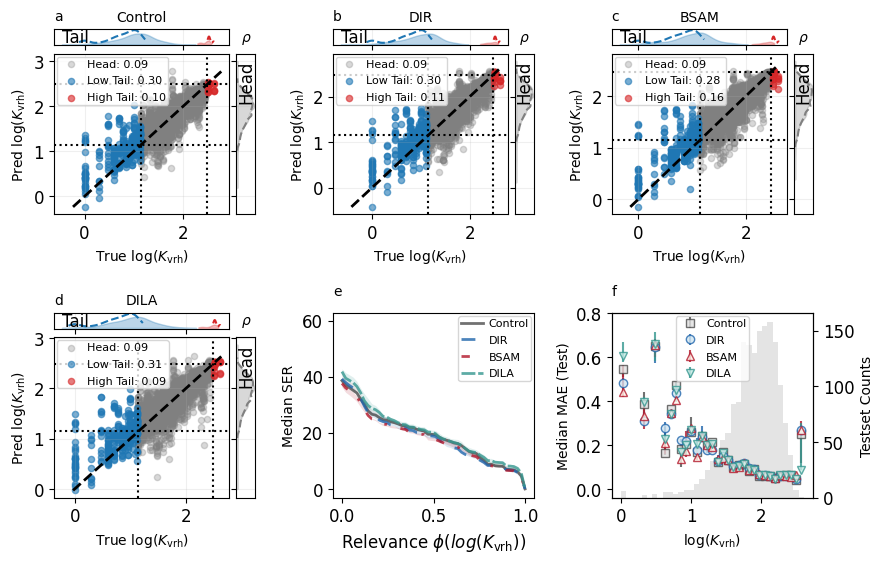


Analysing Fold 2
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.836)
    + Loaded CSV Run 1 (R2: 0.814)
    + Loaded CSV Run 2 (R2: 0.797)
    + Loaded CSV Run 3 (R2: 0.810)
    + Loaded CSV Run 4 (R2: 0.829)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.839)
    + Loaded CSV Run 1 (R2: 0.822)
    + Loaded CSV Run 2 (R2: 0.814)
    + Loaded CSV Run 3 (R2: 0.815)
    + Loaded CSV Run 4 (R2: 0.830)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.850)
    + Loaded CSV Run 1 (R2: 0.808)
    + Loaded CSV Run 2 (R2: 0.825)
    + Loaded CSV Run 3 (R2: 0.845)
    + Loaded CSV Run 4 (R2: 0.833)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.830)
    + Loaded CSV Run 1 (R2: 0.822)
    + Loaded CSV Run 2 (R2: 0.806)
    + Loaded CSV Run 3 (R2: 0.831)
    + Loaded CSV Run 4 (R2: 0.817)


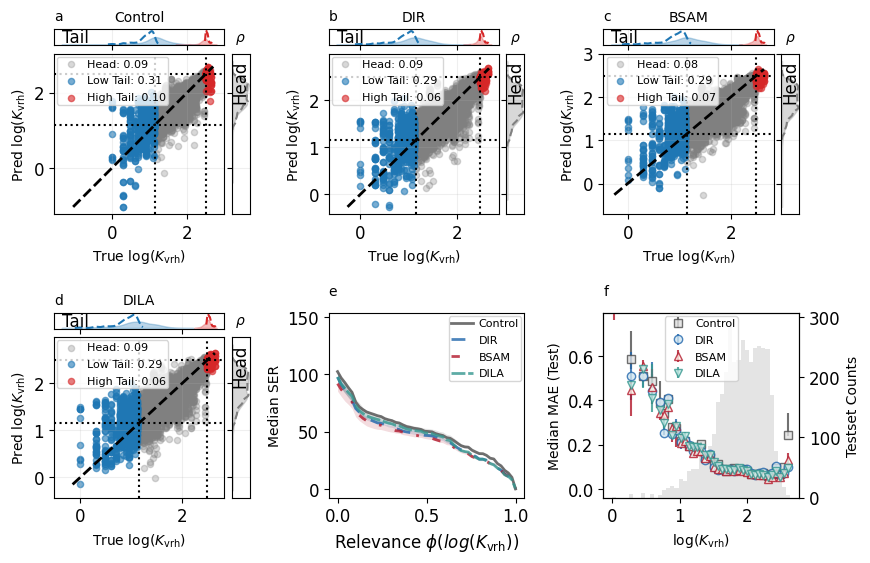


Analysing Fold 3
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.865)
    + Loaded CSV Run 1 (R2: 0.850)
    + Loaded CSV Run 2 (R2: 0.863)
    + Loaded CSV Run 3 (R2: 0.851)
    + Loaded CSV Run 4 (R2: 0.851)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.835)
    + Loaded CSV Run 1 (R2: 0.842)
    + Loaded CSV Run 2 (R2: 0.870)
    + Loaded CSV Run 3 (R2: 0.865)
    + Loaded CSV Run 4 (R2: 0.858)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.868)
    + Loaded CSV Run 1 (R2: 0.855)
    + Loaded CSV Run 2 (R2: 0.880)
    + Loaded CSV Run 3 (R2: 0.853)
    + Loaded CSV Run 4 (R2: 0.861)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.877)
    + Loaded CSV Run 1 (R2: 0.847)
    + Loaded CSV Run 2 (R2: 0.866)
    + Loaded CSV Run 3 (R2: 0.850)
    + Loaded CSV Run 4 (R2: 0.843)


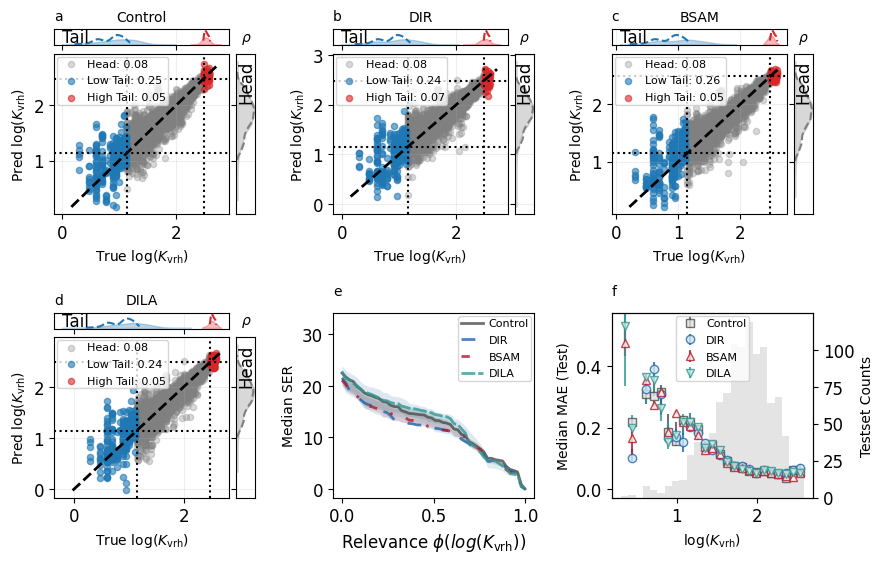


Analysing Fold 4
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.835)
    + Loaded CSV Run 1 (R2: 0.624)
    + Loaded CSV Run 2 (R2: 0.845)
    + Loaded CSV Run 3 (R2: 0.840)
    + Loaded CSV Run 4 (R2: 0.221)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.849)
    + Loaded CSV Run 1 (R2: 0.768)
    + Loaded CSV Run 2 (R2: 0.846)
    + Loaded CSV Run 3 (R2: 0.846)
    + Loaded CSV Run 4 (R2: 0.852)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.835)
    + Loaded CSV Run 1 (R2: 0.830)
    + Loaded CSV Run 2 (R2: 0.851)
    + Loaded CSV Run 3 (R2: 0.847)
    + Loaded CSV Run 4 (R2: 0.835)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.839)
    + Loaded CSV Run 1 (R2: 0.826)
    + Loaded CSV Run 2 (R2: -0.506)
    + Loaded CSV Run 3 (R2: 0.846)
    + Loaded CSV Run 4 (R2: 0.848)
--> Dropped exploded run from ensemble: R2=0.624 (Ensemble Best=0.845)
--> Dropped exploded run from ensemble: R2=0.221 (Ensemble Best=0.845)
--> Dropped exploded run from ensemble: R2=0.768 (Ens

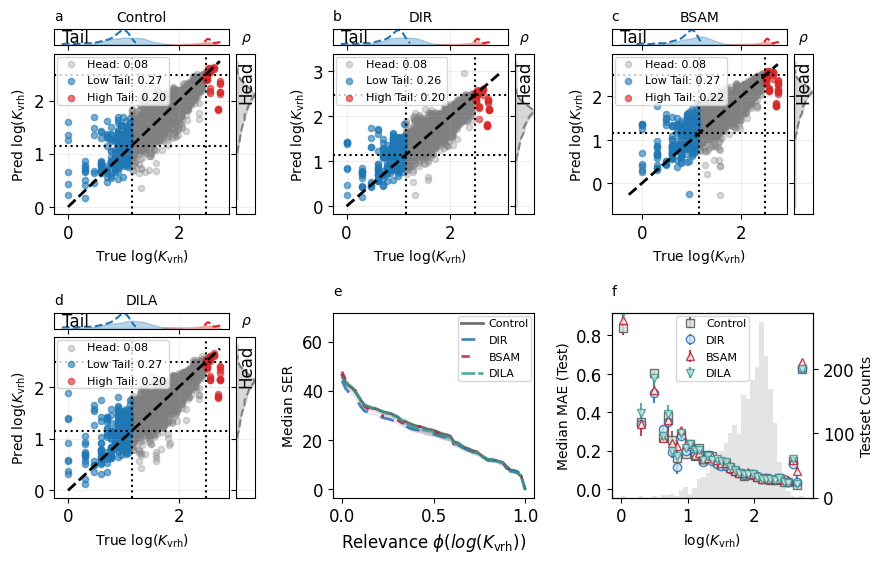


Analysing Fold 0
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.771)
    + Loaded CSV Run 1 (R2: 0.763)
    + Loaded CSV Run 2 (R2: 0.753)
    + Loaded CSV Run 3 (R2: 0.766)
    + Loaded CSV Run 4 (R2: 0.692)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.771)
    + Loaded CSV Run 1 (R2: 0.742)
    + Loaded CSV Run 2 (R2: 0.755)
    + Loaded CSV Run 3 (R2: 0.781)
    + Loaded CSV Run 4 (R2: 0.772)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.792)
    + Loaded CSV Run 1 (R2: 0.759)
    + Loaded CSV Run 2 (R2: 0.783)
    + Loaded CSV Run 3 (R2: 0.788)
    + Loaded CSV Run 4 (R2: 0.776)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.681)
    + Loaded CSV Run 1 (R2: 0.759)
    + Loaded CSV Run 2 (R2: 0.747)
    + Loaded CSV Run 3 (R2: -0.415)
    + Loaded CSV Run 4 (R2: 0.783)
--> Dropped exploded run from ensemble: R2=0.692 (Ensemble Best=0.771)
--> Dropped exploded run from ensemble: R2=0.681 (Ensemble Best=0.783)
--> Dropped exploded run from ensemble: R2=-0.415 (En

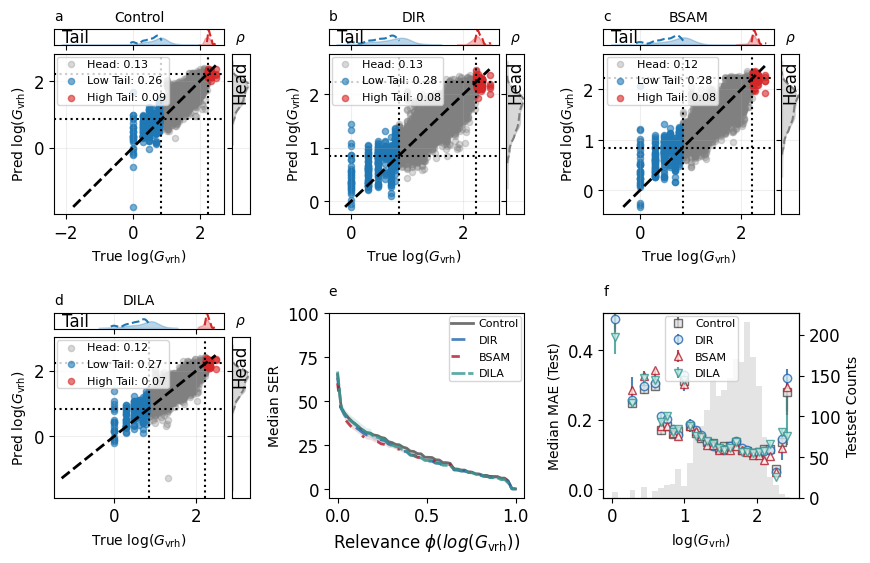


Analysing Fold 1
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.756)
    + Loaded CSV Run 1 (R2: 0.789)
    + Loaded CSV Run 2 (R2: 0.794)
    + Loaded CSV Run 3 (R2: 0.794)
    + Loaded CSV Run 4 (R2: 0.793)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.789)
    + Loaded CSV Run 1 (R2: 0.783)
    + Loaded CSV Run 2 (R2: 0.774)
    + Loaded CSV Run 3 (R2: 0.791)
    + Loaded CSV Run 4 (R2: 0.803)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.784)
    + Loaded CSV Run 1 (R2: 0.801)
    + Loaded CSV Run 2 (R2: 0.786)
    + Loaded CSV Run 3 (R2: 0.789)
    + Loaded CSV Run 4 (R2: 0.794)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.782)
    + Loaded CSV Run 1 (R2: 0.788)
    + Loaded CSV Run 2 (R2: 0.801)
    + Loaded CSV Run 3 (R2: 0.784)
    + Loaded CSV Run 4 (R2: 0.788)


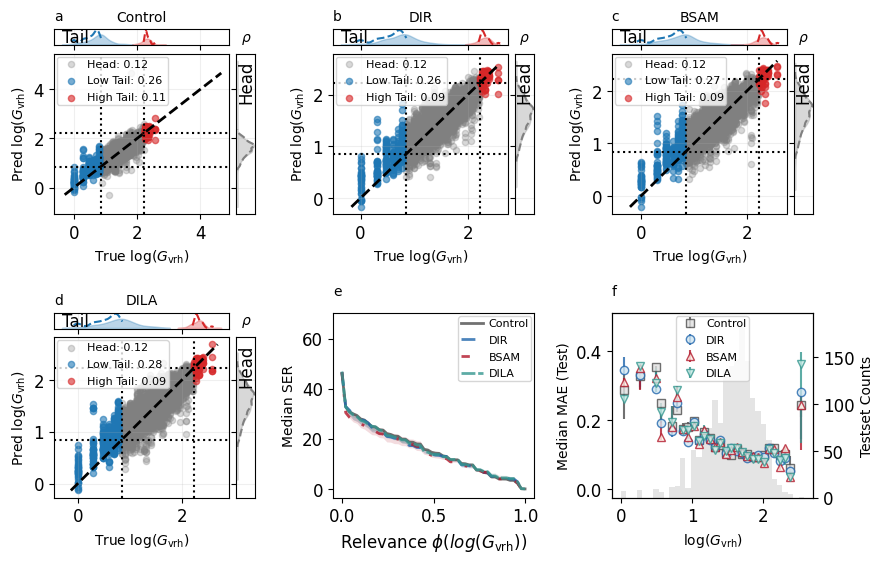


Analysing Fold 2
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.774)
    + Loaded CSV Run 1 (R2: 0.763)
    + Loaded CSV Run 2 (R2: 0.773)
    + Loaded CSV Run 3 (R2: 0.772)
    + Loaded CSV Run 4 (R2: 0.781)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.767)
    + Loaded CSV Run 1 (R2: 0.777)
    + Loaded CSV Run 2 (R2: -0.946)
    + Loaded CSV Run 3 (R2: 0.761)
    + Loaded CSV Run 4 (R2: 0.248)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.799)
    + Loaded CSV Run 1 (R2: 0.793)
    + Loaded CSV Run 2 (R2: 0.790)
    + Loaded CSV Run 3 (R2: 0.776)
    + Loaded CSV Run 4 (R2: 0.787)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.777)
    + Loaded CSV Run 1 (R2: 0.764)
    + Loaded CSV Run 2 (R2: 0.281)
    + Loaded CSV Run 3 (R2: 0.765)
    + Loaded CSV Run 4 (R2: 0.563)
--> Dropped exploded run from ensemble: R2=-0.946 (Ensemble Best=0.777)
--> Dropped exploded run from ensemble: R2=0.248 (Ensemble Best=0.777)
--> Dropped exploded run from ensemble: R2=0.281 (En

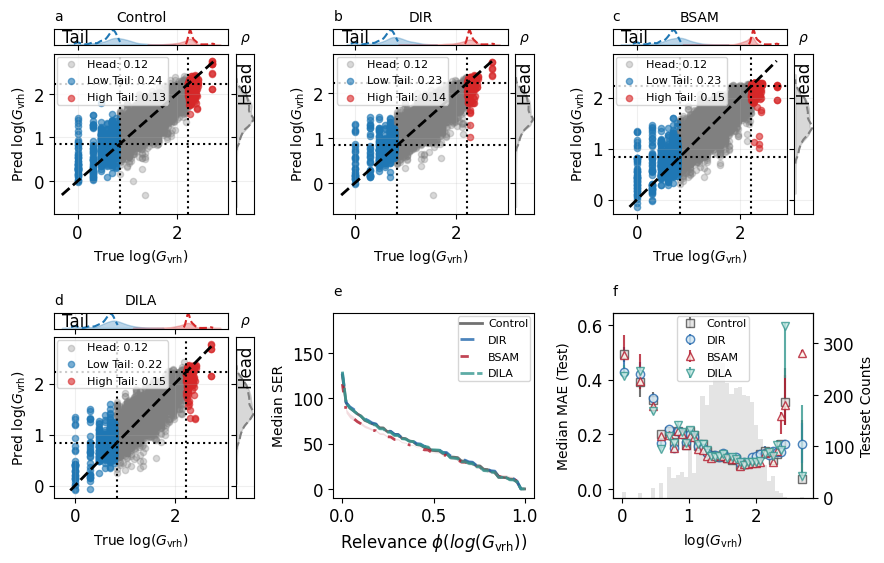


Analysing Fold 3
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.820)
    + Loaded CSV Run 1 (R2: 0.814)
    + Loaded CSV Run 2 (R2: 0.822)
    + Loaded CSV Run 3 (R2: 0.821)
    + Loaded CSV Run 4 (R2: 0.821)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.815)
    + Loaded CSV Run 1 (R2: 0.807)
    + Loaded CSV Run 2 (R2: 0.833)
    + Loaded CSV Run 3 (R2: 0.826)
    + Loaded CSV Run 4 (R2: 0.827)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.806)
    + Loaded CSV Run 1 (R2: 0.810)
    + Loaded CSV Run 2 (R2: 0.820)
    + Loaded CSV Run 3 (R2: 0.821)
    + Loaded CSV Run 4 (R2: 0.827)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.428)
    + Loaded CSV Run 1 (R2: 0.813)
    + Loaded CSV Run 2 (R2: 0.818)
    + Loaded CSV Run 3 (R2: 0.820)
    + Loaded CSV Run 4 (R2: 0.807)
--> Dropped exploded run from ensemble: R2=0.428 (Ensemble Best=0.820)
--> Dropped exploded run from ensemble: R2=0.428 (Ensemble Best=0.820)
--> Dropped exploded run from ensemble: R2=0.428 (Ense

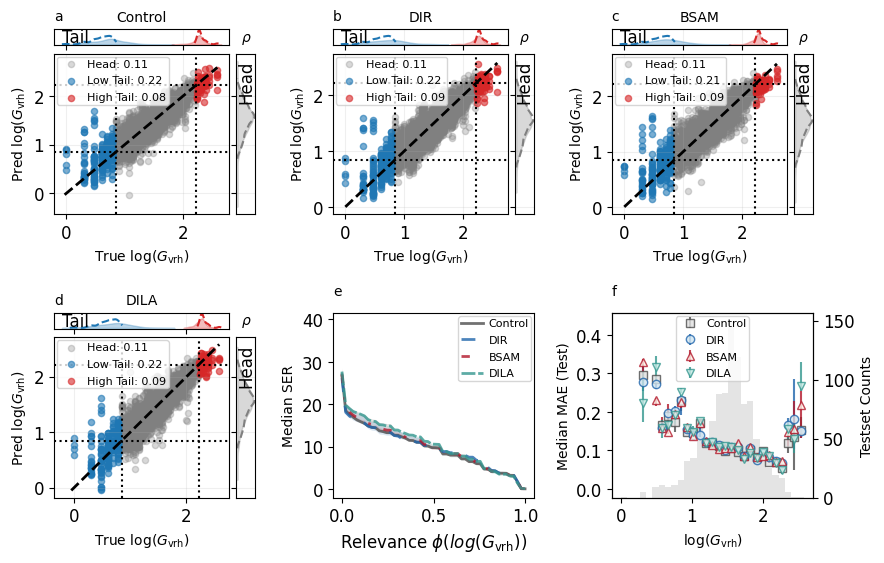


Analysing Fold 4
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.797)
    + Loaded CSV Run 1 (R2: 0.766)
    + Loaded CSV Run 2 (R2: 0.781)
    + Loaded CSV Run 3 (R2: 0.799)
    + Loaded CSV Run 4 (R2: 0.812)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.784)
    + Loaded CSV Run 1 (R2: 0.757)
    + Loaded CSV Run 2 (R2: 0.807)
    + Loaded CSV Run 3 (R2: 0.788)
    + Loaded CSV Run 4 (R2: 0.797)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.805)
    + Loaded CSV Run 1 (R2: 0.803)
    + Loaded CSV Run 2 (R2: 0.814)
    + Loaded CSV Run 3 (R2: 0.799)
    + Loaded CSV Run 4 (R2: 0.808)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.784)
    + Loaded CSV Run 1 (R2: 0.707)
    + Loaded CSV Run 2 (R2: 0.793)
    + Loaded CSV Run 3 (R2: 0.790)
    + Loaded CSV Run 4 (R2: 0.804)
--> Dropped exploded run from ensemble: R2=0.707 (Ensemble Best=0.804)
--> Dropped exploded run from ensemble: R2=0.707 (Ensemble Best=0.804)
--> Dropped exploded run from ensemble: R2=0.707 (Ense

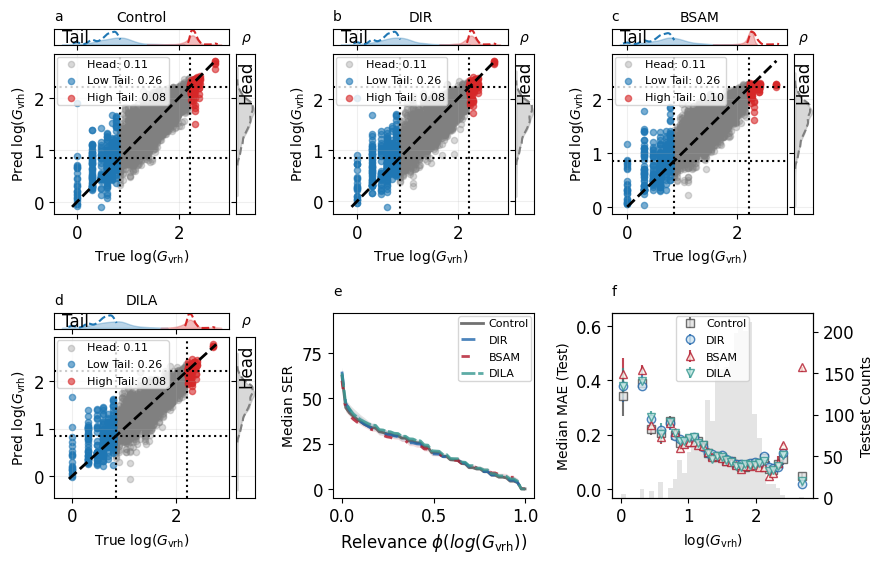


Analysing Fold 0
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.970)
    + Loaded CSV Run 1 (R2: 0.963)
    + Loaded CSV Run 2 (R2: 0.970)
    + Loaded CSV Run 3 (R2: 0.971)
    + Loaded CSV Run 4 (R2: 0.969)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.957)
    + Loaded CSV Run 1 (R2: 0.965)
    + Loaded CSV Run 2 (R2: 0.973)
    + Loaded CSV Run 3 (R2: 0.971)
    + Loaded CSV Run 4 (R2: 0.968)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.966)
    + Loaded CSV Run 1 (R2: 0.970)
    + Loaded CSV Run 2 (R2: 0.972)
    + Loaded CSV Run 3 (R2: 0.969)
    + Loaded CSV Run 4 (R2: 0.960)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.967)
    + Loaded CSV Run 1 (R2: 0.968)
    + Loaded CSV Run 2 (R2: 0.969)
    + Loaded CSV Run 3 (R2: 0.966)
    + Loaded CSV Run 4 (R2: 0.971)
Singular matrix in KDE for Low Tail GT
Singular matrix in KDE for Low Tail GT
Singular matrix in KDE for Low Tail GT
Singular matrix in KDE for Low Tail GT


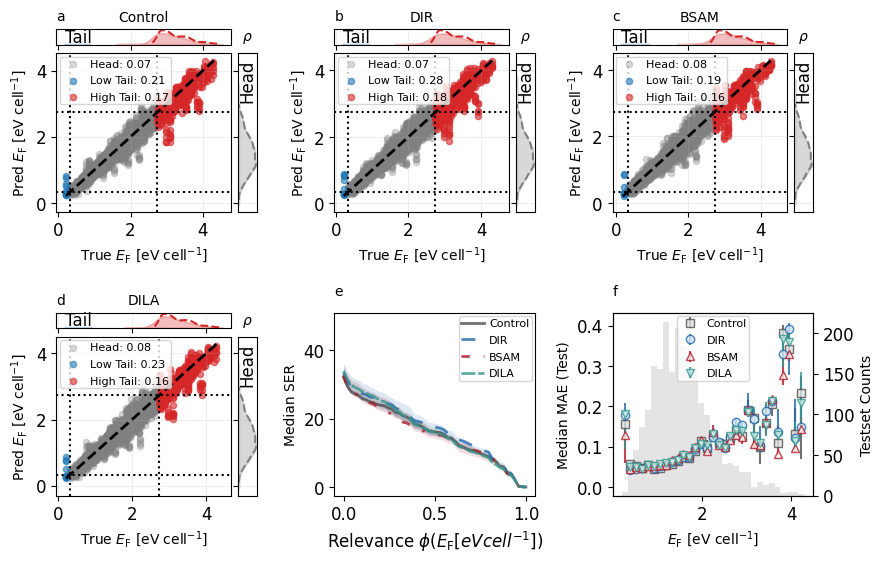


Analysing Fold 1
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.950)
    + Loaded CSV Run 1 (R2: 0.949)
    + Loaded CSV Run 2 (R2: 0.947)
    + Loaded CSV Run 3 (R2: 0.957)
    + Loaded CSV Run 4 (R2: 0.959)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.952)
    + Loaded CSV Run 1 (R2: 0.949)
    + Loaded CSV Run 2 (R2: 0.938)
    + Loaded CSV Run 3 (R2: 0.955)
    + Loaded CSV Run 4 (R2: 0.963)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.946)
    + Loaded CSV Run 1 (R2: 0.939)
    + Loaded CSV Run 2 (R2: 0.953)
    + Loaded CSV Run 3 (R2: 0.957)
    + Loaded CSV Run 4 (R2: 0.945)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.946)
    + Loaded CSV Run 1 (R2: 0.952)
    + Loaded CSV Run 2 (R2: 0.942)
    + Loaded CSV Run 3 (R2: 0.963)
    + Loaded CSV Run 4 (R2: 0.958)


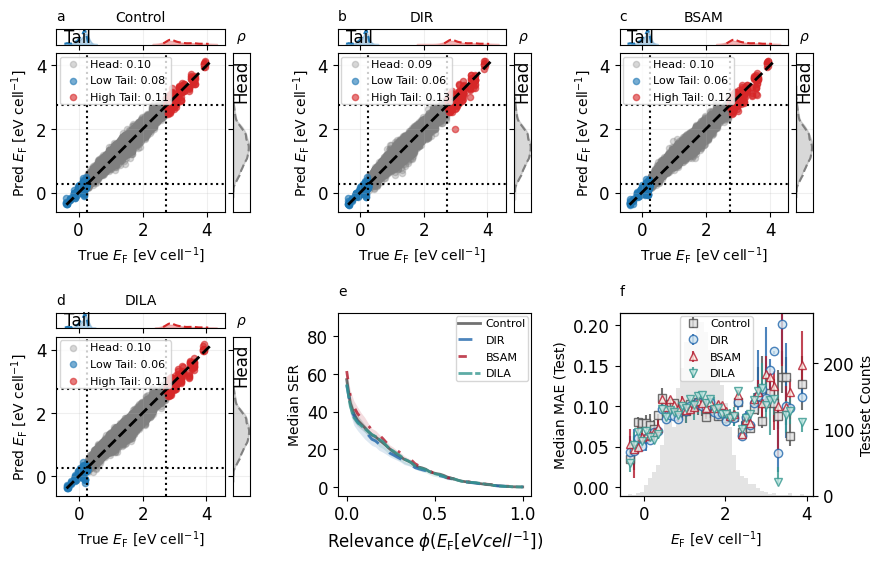


Analysing Fold 2
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.971)
    + Loaded CSV Run 1 (R2: 0.973)
    + Loaded CSV Run 2 (R2: 0.973)
    + Loaded CSV Run 3 (R2: 0.977)
    + Loaded CSV Run 4 (R2: 0.969)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.976)
    + Loaded CSV Run 1 (R2: 0.967)
    + Loaded CSV Run 2 (R2: 0.973)
    + Loaded CSV Run 3 (R2: 0.979)
    + Loaded CSV Run 4 (R2: 0.964)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.976)
    + Loaded CSV Run 1 (R2: 0.975)
    + Loaded CSV Run 2 (R2: 0.977)
    + Loaded CSV Run 3 (R2: 0.965)
    + Loaded CSV Run 4 (R2: 0.965)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.970)
    + Loaded CSV Run 1 (R2: 0.963)
    + Loaded CSV Run 2 (R2: 0.969)
    + Loaded CSV Run 3 (R2: 0.976)
    + Loaded CSV Run 4 (R2: 0.970)


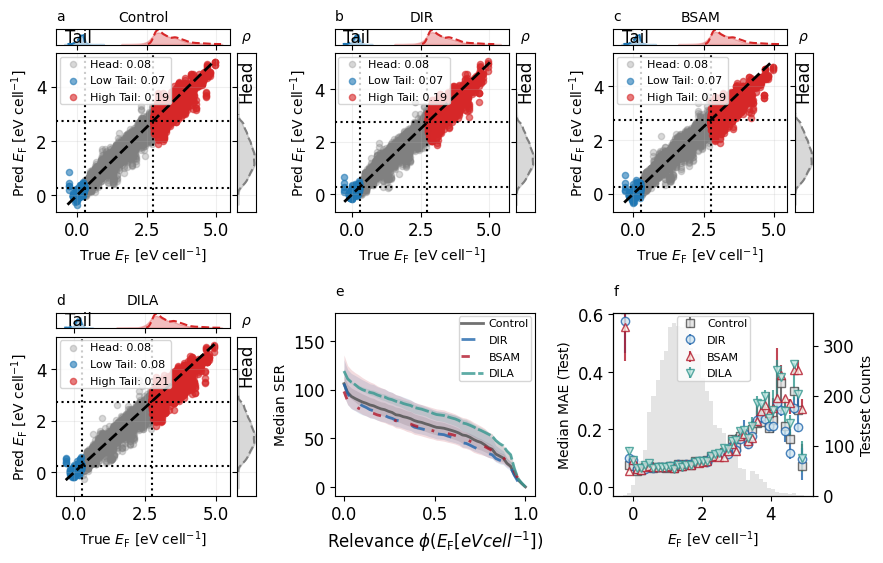


Analysing Fold 3
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.985)
    + Loaded CSV Run 1 (R2: 0.984)
    + Loaded CSV Run 2 (R2: 0.987)
    + Loaded CSV Run 3 (R2: 0.985)
    + Loaded CSV Run 4 (R2: 0.987)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.987)
    + Loaded CSV Run 1 (R2: 0.987)
    + Loaded CSV Run 2 (R2: 0.988)
    + Loaded CSV Run 3 (R2: 0.987)
    + Loaded CSV Run 4 (R2: 0.987)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.983)
    + Loaded CSV Run 1 (R2: 0.982)
    + Loaded CSV Run 2 (R2: 0.985)
    + Loaded CSV Run 3 (R2: 0.984)
    + Loaded CSV Run 4 (R2: 0.976)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.986)
    + Loaded CSV Run 1 (R2: 0.985)
    + Loaded CSV Run 2 (R2: 0.983)
    + Loaded CSV Run 3 (R2: 0.987)
    + Loaded CSV Run 4 (R2: 0.983)


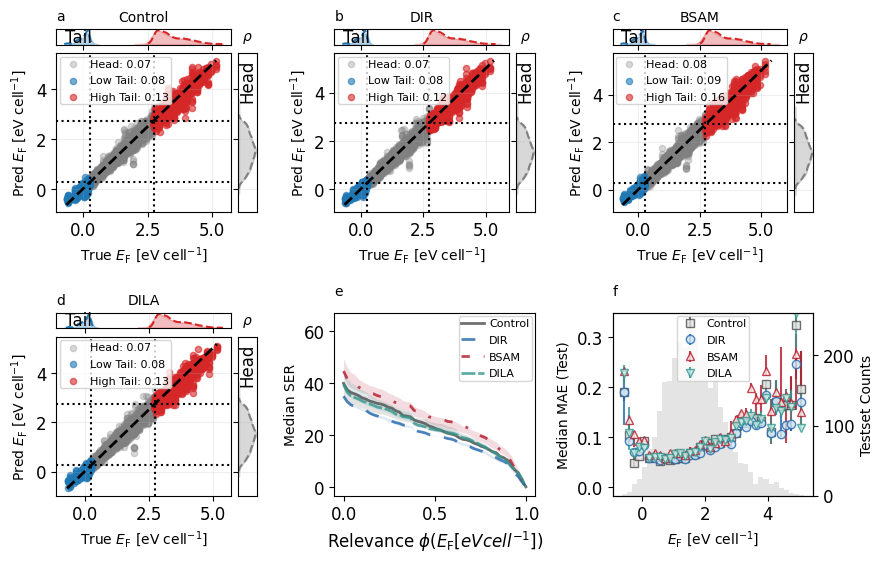


Analysing Fold 4
  Evaluating Control...
    + Loaded CSV Run 0 (R2: 0.763)
    + Loaded CSV Run 1 (R2: 0.765)
    + Loaded CSV Run 2 (R2: 0.794)
    + Loaded CSV Run 3 (R2: 0.838)
    + Loaded CSV Run 4 (R2: 0.774)
  Evaluating DIR...
    + Loaded CSV Run 0 (R2: 0.736)
    + Loaded CSV Run 1 (R2: 0.773)
    + Loaded CSV Run 2 (R2: 0.786)
    + Loaded CSV Run 3 (R2: 0.801)
    + Loaded CSV Run 4 (R2: 0.770)
  Evaluating BSAM...
    + Loaded CSV Run 0 (R2: 0.697)
    + Loaded CSV Run 1 (R2: 0.805)
    + Loaded CSV Run 2 (R2: 0.776)
    + Loaded CSV Run 3 (R2: 0.802)
    + Loaded CSV Run 4 (R2: 0.791)
  Evaluating DILA...
    + Loaded CSV Run 0 (R2: 0.701)
    + Loaded CSV Run 1 (R2: 0.700)
    + Loaded CSV Run 2 (R2: 0.802)
    + Loaded CSV Run 3 (R2: 0.791)
    + Loaded CSV Run 4 (R2: 0.788)
--> Dropped exploded run from ensemble: R2=0.763 (Ensemble Best=0.838)
--> Dropped exploded run from ensemble: R2=0.765 (Ensemble Best=0.838)
--> Dropped exploded run from ensemble: R2=0.774 (Ense

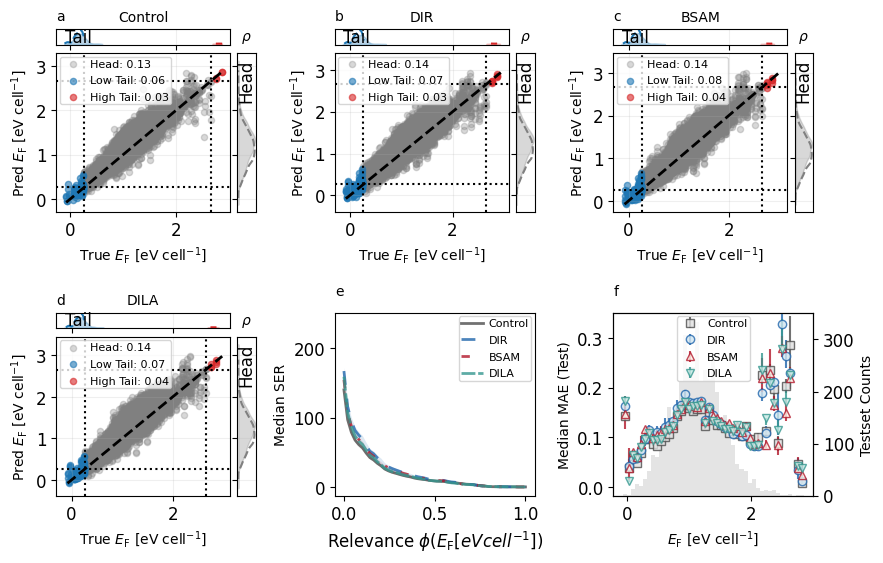

In [12]:
configs_dir='expt_configs/matfold'
base_dir = "experiments/matfold"
datasets = ['phonons', 'log_kvrh', 'log_gvrh', 'perovskites']
math_names = [ r"$\nu _{\mathrm{{last}}}$ [cm$^{-1}$]", r"log($K_{\mathrm{{vrh}}}$)", r"log($G_{\mathrm{{vrh}}}$)", r"$E_{\mathrm{{F}}}$ [eV cell$^{-1}$]"]

for dataset, math_name in zip(datasets, math_names):
    globals()[f"matfold_{dataset}_analysers"], globals()[f"matfold_{dataset}_results"] = analyse_dataset(
        dataset, target_name = math_name, configs_dir=configs_dir,results_dir=base_dir, fig_prefix='matfold'
    )

In [8]:
all_dataset_analysers = {}

for dataset in ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']:
    all_dataset_analysers[dataset] = globals()[f"matfold_{dataset}_analysers"]

# Generate the LaTeX table all at once
generate_comprehensive_metrics_table(all_dataset_analysers, table_name='matfold_comprehensive_metrics_table.txt')


Analysing Metrics for: log_kvrh
--> Dropped exploded run from ensemble: R2=0.624 (Ensemble Best=0.845)
--> Dropped exploded run from ensemble: R2=0.221 (Ensemble Best=0.845)
--> Dropped exploded run from ensemble: R2=0.674 (Ensemble Best=0.828)
--> Dropped exploded run from ensemble: R2=0.768 (Ensemble Best=0.852)
--> Dropped exploded run from ensemble: R2=-0.506 (Ensemble Best=0.848)

Analysing Metrics for: log_gvrh
--> Dropped exploded run from ensemble: R2=0.692 (Ensemble Best=0.771)
--> Dropped exploded run from ensemble: R2=-0.946 (Ensemble Best=0.777)
--> Dropped exploded run from ensemble: R2=0.248 (Ensemble Best=0.777)
--> Dropped exploded run from ensemble: R2=0.681 (Ensemble Best=0.783)
--> Dropped exploded run from ensemble: R2=-0.415 (Ensemble Best=0.783)
--> Dropped exploded run from ensemble: R2=0.281 (Ensemble Best=0.777)
--> Dropped exploded run from ensemble: R2=0.563 (Ensemble Best=0.777)
--> Dropped exploded run from ensemble: R2=0.428 (Ensemble Best=0.820)
--> Drop

## Fig 4. Out of distribution discovery metrics

In [15]:
def calc_imba_metrics(imba_analysers, rel_thresholds = np.linspace(0.5, 0.9, num = 9),
                      budget_ratios= np.linspace(0.5, 3, num = 11), discover_mode = 'high'):
    all_results = []
    for fold, imba_analyser in enumerate(imba_analysers):
        for rel_threshold in rel_thresholds:
            for budget_ratio in budget_ratios:
                for i, method in enumerate(imba_analyser.labels):
                    results = imba_analyser.calculate_adaptive_discovery_metrics(
                        imba_analyser.all_preds[i], budget_ratio=budget_ratio, rel_threshold = rel_threshold, discover_mode = discover_mode
                    )
                    
                    # --- THE FIX: Skip this configuration if the tail is empty ---
                    if 'Error' in results:
                        continue 
                    # -------------------------------------------------------------

                    # Filter the dictionary for the keys you need
                    filtered_results = {key: results[key] for key in [
                        'Discovery Mode', 'Tail Size (GT)', 'Extrap. Precision',
                        'Tail Recall', 'Tail MAE',
                        'Breakdown'
                    ]}
                    filtered_results.update({
                        'Method': method,
                        'Rel Threshold': rel_threshold,
                        'Budget Ratio': budget_ratio,
                        'Fold': fold
                    })
            
                    # Collect the dictionary in a list
                    all_results.append(filtered_results)

    # Create the final DataFrame from the list of dictionaries
    df = pd.DataFrame(all_results)
    return df

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_discovery_analysis(df, axes=None, rel_threshold=0.5, save_path=None):
    """
    Generates a comprehensive Discovery Performance analysis figure.
    Plots Efficiency (Precision), Completeness (Recall), and Error (MAE).
    """
    # 1. Filter Data for the specific difficulty level
    subset = df[df['Rel Threshold'] == rel_threshold].copy()
    
    if subset.empty:
        print(f"No data found for Rel Threshold = {rel_threshold}")
        return

    if axes is None:
        fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.8), constrained_layout=True)
    
    # 3. Define EXACT formatting mapped from compare_mae_wb & analyse_method_sensitivity
    models = sorted(subset['Method'].unique())
    e_colors = ['#4d4d4d', '#2166ac', '#b2182b', '#35978f', '#ff7f0e'] 
    f_colors = ['#e0e0e0', '#d1e5f0', '#fff5eb', '#c7eae5', '#ffbb78']
    markers = ['s', 'o', '^', 'v', 'D']
    
    # Helper for consistent lineplots
    def plot_metric(ax, metric_col, ylabel, show_legend=False):
        # We loop through methods to explicitly control marker face/edge colors
        for i, method in enumerate(['Control', 'DIR', 'BSAM', 'DILA']):
            c_idx = i % len(e_colors)
            
            sns.lineplot(
                data=subset[subset['Method'] == method], 
                x='Budget Ratio', 
                y=metric_col,
                ax=ax, 
                color=e_colors[c_idx],       # Line and CI Band color
                linewidth=1.5, 
                errorbar=('ci', 95),         # 95% Confidence Interval
                err_style='band', 
                label=method if show_legend else None,
                # --- EXACT MARKER FORMATTING ---
                marker=markers[c_idx],
                markersize=7,
                markeredgecolor=e_colors[c_idx],
                markerfacecolor=f_colors[c_idx]
            )
            
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xlabel('Budget Ratio (x Tail Size)', fontsize=10)
        ax.axvline(1.0, color='#555555', linestyle='--', alpha=0.6)
        
        if show_legend:
            ax.legend(fontsize=8, loc='best')

    # --- Panel A: Efficiency (Precision) ---
    plot_metric(
        axes[0], 'Extrap. Precision', 
        'Success Rate (Precision)'
    )
    
    # --- Panel B: Completeness (Recall) ---
    plot_metric(
        axes[1], 'Tail Recall', 
        'Fraction Found (Recall)',
        show_legend=True # Show legend on middle plot
    )
    
    # --- Panel C: Quality (Tail MAE) ---
    plot_metric(
        axes[2], 'Tail MAE', 
        'Tail MAE (eV)'
    )
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        
    if axes is None:
        plt.show()

#### CV

In [17]:
phonons_metrics = calc_imba_metrics(phonons_analysers, discover_mode = 'high')
phonons_metrics.to_csv('results/phonons_discov_metrics.csv', index = None)
log_kvrh_metrics = calc_imba_metrics(log_kvrh_analysers, discover_mode = 'high')
log_kvrh_metrics.to_csv('results/log_kvrh_discov_metrics.csv', index = None)
log_gvrh_metrics = calc_imba_metrics(log_gvrh_analysers, discover_mode = 'high')
log_gvrh_metrics.to_csv('results/log_gvrh_discov_metrics.csv', index = None)
perovskites_metrics = calc_imba_metrics(perovskites_analysers, discover_mode = 'low')
perovskites_metrics.to_csv('results/perovskites_discov_metrics.csv', index = None)

--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dr

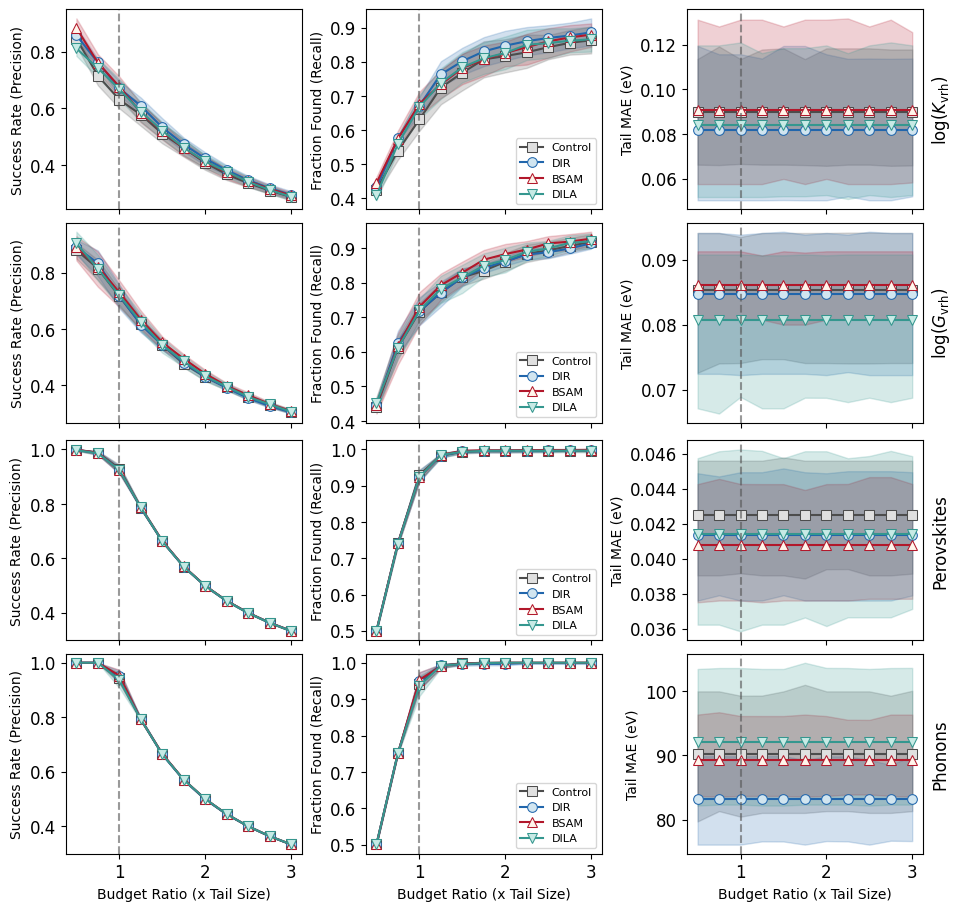

In [18]:
log_kvrh_results=pd.read_csv("results/log_kvrh_discov_metrics.csv")
log_gvrh_results=pd.read_csv("results/log_gvrh_discov_metrics.csv")
phonons_results = pd.read_csv("results/phonons_discov_metrics.csv")
perovskites_results=pd.read_csv("results/perovskites_discov_metrics.csv")

fig, (axes1, axes2, axes3, axes4)=plt.subplots(4,3, figsize=(9.5, 9), sharex='col', layout = 'compressed')
plot_discovery_analysis(log_kvrh_results, axes=axes1, rel_threshold=0.75)
plot_discovery_analysis(log_gvrh_results, axes=axes2, rel_threshold=0.75)
plot_discovery_analysis(perovskites_results, axes=axes3, rel_threshold=0.75)
plot_discovery_analysis(phonons_results, axes=axes4, rel_threshold=0.75)

datasets=[r"log($K_{\mathrm{vrh}}$)", r"log($G_{\mathrm{vrh}}$)", 'Perovskites', 'Phonons']
for i, axes in enumerate((axes1, axes2, axes3, axes4)):
    axes[-1].text(1.075, 0.5, datasets[i], va='center', ha='center', rotation=90, transform=axes[-1].transAxes)

plt.savefig('figs/paper_final/discov_performance.jpg', dpi=600)

#### MatFold

In [20]:
phonons_metrics = calc_imba_metrics(matfold_phonons_analysers, discover_mode = 'high')
phonons_metrics.to_csv('results/phonons_matfold_discov_metrics.csv', index = None)
log_kvrh_metrics = calc_imba_metrics(matfold_log_kvrh_analysers, discover_mode = 'high')
log_kvrh_metrics.to_csv('results/log_kvrh_matfold_discov_metrics.csv', index = None)
log_gvrh_metrics = calc_imba_metrics(matfold_log_gvrh_analysers, discover_mode = 'high')
log_gvrh_metrics.to_csv('results/log_gvrh_matfold_discov_metrics.csv', index = None)
perovskites_metrics = calc_imba_metrics(matfold_perovskites_analysers, discover_mode = 'low')
perovskites_metrics.to_csv('results/perovskites_matfold_discov_metrics.csv', index = None)

--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-78051.788 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-78051.788 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-78051.788 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-78051.788 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-78051.788 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-78051.788 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: R2=-8.346 (Ensemble Best=0.984)
--> Dropped exploded run from ensemble: 

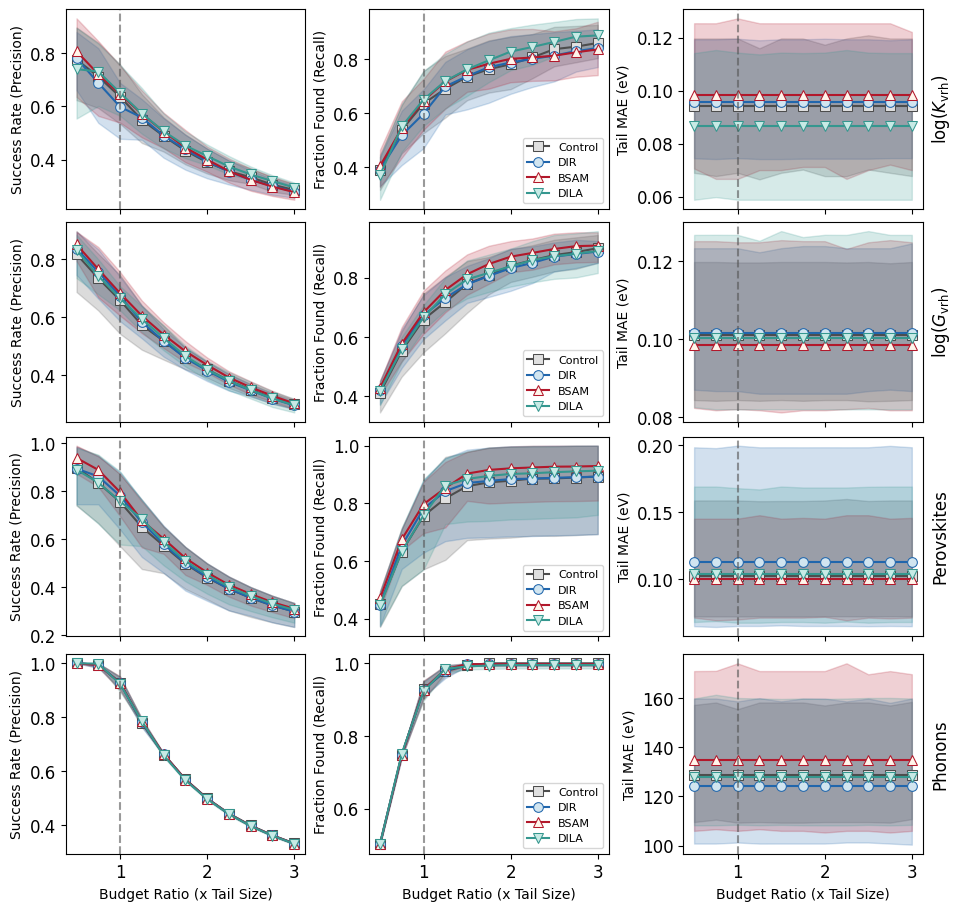

In [22]:
log_kvrh_results=pd.read_csv("results/log_kvrh_matfold_discov_metrics.csv")
log_gvrh_results=pd.read_csv("results/log_gvrh_matfold_discov_metrics.csv")
phonons_results = pd.read_csv("results/phonons_matfold_discov_metrics.csv")
perovskites_results=pd.read_csv("results/perovskites_matfold_discov_metrics.csv")

fig, (axes1, axes2, axes3, axes4)=plt.subplots(4,3, figsize=(9.5, 9), sharex='col', layout = 'compressed')
plot_discovery_analysis(log_kvrh_results, axes=axes1, rel_threshold=0.75)
plot_discovery_analysis(log_gvrh_results, axes=axes2, rel_threshold=0.75)
plot_discovery_analysis(perovskites_results, axes=axes3, rel_threshold=0.75)
plot_discovery_analysis(phonons_results, axes=axes4, rel_threshold=0.75)

datasets=[r"log($K_{\mathrm{vrh}}$)", r"log($G_{\mathrm{vrh}}$)", 'Perovskites', 'Phonons']
for i, axes in enumerate((axes1, axes2, axes3, axes4)):
    axes[-1].text(1.075, 0.5, datasets[i], va='center', ha='center', rotation=90, transform=axes[-1].transAxes)

plt.savefig('figs/paper_final/matfold_discov_performance.jpg', dpi=600)

## Fig 5. SERA & alpha performance of Matbench datasets

In [48]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import r2_score
from MatImba.utils.losses import calc_sera

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Knowledge Base: Dataset Indices ---
DATASET_META = {
    'log_kvrh':    {'h': 0.516, 'w1': 0.207},
    'log_gvrh':    {'h': 0.498, 'w1': 0.153},
    'phonons':     {'h': 0.631, 'w1': 0.354},
    'perovskites': {'h': 0.521, 'w1': 0.186}
}

# --- MINIMAL CHANGE: Compute PCA for h and w1 ---
meta_df = pd.DataFrame.from_dict(DATASET_META, orient='index')
scaler = StandardScaler()
coords = PCA(n_components=2).fit_transform(scaler.fit_transform(meta_df[['h', 'w1']]))

for i, ds_name in enumerate(meta_df.index):
    DATASET_META[ds_name]['PC1'] = coords[i, 0]
    DATASET_META[ds_name]['PC2'] = coords[i, 1]

import numpy as np
import pandas as pd
from MatImba.utils.losses import calc_sera

def extract_robust_metrics(dataset, analysers, sera_t_threshold=0.8):
    """
    Extracts SERA and Alpha metrics directly from the list of imba_analyser 
    objects returned by analyse_dataset, utilizing their internal _filter_bad_runs.
    """
    # Safety: ensure it's a list even if a single analyser object is passed
    if not isinstance(analysers, list):
        analysers = [analysers]
        
    metrics_dict = {}
    if not analysers:
        return pd.DataFrame()

    # The labels (methods) are natively stored in the analyser object
    methods = analysers[0].labels

    for i, method in enumerate(methods):
        valid_folds = []
        
        # Each analyser in the list represents one fold
        for fold, analyser in enumerate(analysers):
            if i >= len(analyser.all_preds): continue
            
            # --- MINIMAL CHANGE: Use the analyser's native filter in memory ---
            raw_runs = analyser.all_preds[i]
            valid_runs = analyser._filter_bad_runs(raw_runs)
            
            if not valid_runs: continue
            
            # Extract arrays directly from the valid run objects
            labels = np.concatenate([np.ravel(p.targets) for p in valid_runs])
            preds = np.concatenate([np.ravel(p.preds) for p in valid_runs])
            maes = np.abs(labels - preds)
            
            # 1. Compute SERA
            if hasattr(valid_runs[0], 'relevances') and valid_runs[0].relevances is not None:
                relevances = np.concatenate([np.ravel(p.relevances) for p in valid_runs])
                sera_val = calc_sera(labels, preds, relevances, t=sera_t_threshold)
                sera_val = float(sera_val.item()) if hasattr(sera_val, 'item') else float(sera_val)
            else:
                sera_val = np.nan
                
            # 2. Compute Alpha
            if hasattr(valid_runs[0], 'densities') and valid_runs[0].densities is not None:
                densities = np.concatenate([np.ravel(p.densities) for p in valid_runs])
                valid_den_mask = densities > 0
                if valid_den_mask.sum() > 1:
                    corr_matrix = np.corrcoef(1 / densities[valid_den_mask], maes[valid_den_mask])
                    alpha_val = float(1 - np.abs(corr_matrix[0][-1]))
                else:
                    alpha_val = np.nan
            else:
                alpha_val = np.nan
                
            valid_folds.append({
                'fold': fold,
                'test_sera': sera_val,
                'test_awareness': alpha_val
            })
            
        if valid_folds:
            metrics_dict[method] = pd.DataFrame(valid_folds)

    # --- Identify the Control baseline dynamically ---
    ctrl_key = next((k for k in metrics_dict.keys() if k.lower() == 'control'), None)
    
    if not ctrl_key:
        print(f"Warning: No valid control data found for {dataset}")
        return pd.DataFrame()
        
    ctrl_sera_mean = metrics_dict[ctrl_key]['test_sera'].mean()
    ctrl_alpha_mean = metrics_dict[ctrl_key]['test_awareness'].mean()
    
    rows = []
    for method, method_df in metrics_dict.items():
        if method == ctrl_key: continue
        
        # Clean up method name for plotting
        prefix = 'DILA' if 'dila' in method.lower() else method.upper()
        
        for _, fold_row in method_df.iterrows():
            sera_val = fold_row['test_sera']
            alpha_val = fold_row['test_awareness']
            
            # Calculate metrics relative to the Control mean
            sera_delta = ((ctrl_sera_mean - sera_val) / ctrl_sera_mean) * 100
            alpha_gain = alpha_val - ctrl_alpha_mean
            
            rows.append({
                'dataset': dataset,
                'method': prefix,
                'sera_delta': float(sera_delta) if pd.notnull(sera_delta) else np.nan,
                'alpha_gain': float(alpha_gain) if pd.notnull(alpha_gain) else np.nan
            })
            
    return pd.DataFrame(rows)

def aggregate_datasets(results_map, meta_data):
    """Aggregates all dataset dataframes into one master long-format dataframe."""
    dfs = []
    for ds_name, df in results_map.items():
        if df.empty: continue
        df_copy = df.copy()
        
        if ds_name in meta_data:
            df_copy['h_index'] = meta_data[ds_name]['h']
            df_copy['w1_dist'] = meta_data[ds_name]['w1']
            # --- MINIMAL CHANGE: Add PC columns ---
            df_copy['PC1'] = meta_data[ds_name]['PC1']
            df_copy['PC2'] = meta_data[ds_name]['PC2']
            
        dfs.append(df_copy)
    return pd.concat(dfs, ignore_index=True)

# --- ANALYSIS: Styled CI Plotter with Top Spine Ticks ---
def analyse_method_sensitivity(df, ax, x_metric='h_index', performance='sera', 
                               is_top_row=False, estimator='median', error_type='sem'):
    """
    Plots performance metric against dataset difficulty.
    Upgraded to use statistically robust estimators (Median + SEM) to prevent 
    heavy-tailed metrics like SERA from exploding the error bars.
    """

    y_metric = 'sera_delta' if performance == 'sera' else 'alpha_gain'
    
    # Exact formatting mapped from compare_mae_wb
    e_colors = ['#2166ac', '#b2182b', '#35978f'] 
    f_colors = ['#d1e5f0', '#fff5eb', '#c7eae5']
    markers = ['o', '^', 'v']
    method_names = ['DIR', 'BSAM', 'DILA']
    
    x_min, x_max = df[x_metric].min(), df[x_metric].max()
    offset_step = (x_max - x_min) * 0.015 if x_max > x_min else 0.01

    for idx, name in enumerate(method_names):
        method_df = df[df['method'] == name]
        if method_df.empty: continue
        
        # --- ROBUST STATISTICAL AGGREGATION ---
        # Calculate the central tendency (Mean or Median)
        if estimator == 'median':
            grouped_center = method_df.groupby(x_metric)[y_metric].median().reset_index(name='center')
        else:
            grouped_center = method_df.groupby(x_metric)[y_metric].mean().reset_index(name='center')
            
        # Calculate the dispersion (Std, Count, and SEM/CI)
        grouped_stats = method_df.groupby(x_metric)[y_metric].agg(['count', 'std']).reset_index()
        grouped = pd.merge(grouped_center, grouped_stats, on=x_metric)
        
        # Determine Error Bar Size
        if error_type == 'sem':
            # Standard Error of the Mean (Tight, robust bounds)
            grouped['error'] = grouped['std'] / np.sqrt(grouped['count'])
        elif error_type == 'ci95':
            # 95% Confidence Interval (Large, heavily penalized by small N)
            grouped['error'] = grouped.apply(
                lambda row: stats.t.ppf(0.975, df=row['count']-1) * (row['std'] / np.sqrt(row['count'])) 
                if row['count'] > 1 and pd.notnull(row['std']) else 0, 
                axis=1
            )
        elif error_type == 'iqr' and estimator == 'median':
             # Interquartile Range (If you want purely non-parametric bounds)
             q1 = method_df.groupby(x_metric)[y_metric].quantile(0.25).reset_index(name='q1')
             q3 = method_df.groupby(x_metric)[y_metric].quantile(0.75).reset_index(name='q3')
             grouped = pd.merge(grouped, q1, on=x_metric)
             grouped = pd.merge(grouped, q3, on=x_metric)
             # Error format for matplotlib: shape(2, N) -> [lower_errors, upper_errors]
             grouped['err_lower'] = grouped['center'] - grouped['q1']
             grouped['err_upper'] = grouped['q3'] - grouped['center']
        
        # --- PLOTTING ---
        # Slight jitter to prevent exact overlap
        x_vals = grouped[x_metric] + ((idx - 1) * offset_step)
        
        if error_type == 'iqr' and estimator == 'median':
            yerr = [grouped['err_lower'], grouped['err_upper']]
        else:
            yerr = grouped['error']
        
        # Plot with exact formatting from compare_mae_wb
        ax.errorbar(
            x_vals, grouped['center'], yerr=yerr,
            c=e_colors[idx], marker=markers[idx], ms=7,
            markerfacecolor=f_colors[idx], alpha=0.8, label=name,
            linestyle='none', capsize=0, elinewidth=1.5
        )

    ax.axhline(0, color='black', lw=1.5, alpha=0.4, linestyle=':')
    
    # --- MINIMAL CHANGE: Add PC1/PC2 labels ---
    if x_metric == 'h_index': x_label = "Distribution Imbalance ($h$)"
    elif x_metric == 'w1_dist': x_label = r"Wasserstein Distance ($W_1$)"
    elif x_metric == 'PC1': x_label = f"PC1: ({pca.explained_variance_ratio_[0]:.1%} var) Statistical\n Imbalance Magnitude"
    elif x_metric == 'PC2': x_label = f"PC2: ({pca.explained_variance_ratio_[1]:.1%} var)\n Geometric Transport Cost"
    else: x_label = x_metric
    
    ax.set_xlabel(x_label, fontsize=10)
    
    if not is_top_row:
        ax.legend(loc='best', fontsize=8)

    # --- TOP SPINE TEXT TICKS ---
    if is_top_row:
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        
        unique_ds = df[[x_metric, 'dataset']].drop_duplicates().sort_values(by=x_metric)
        
        def format_ds_name(name):
            if name == 'log_kvrh': return r"$\log(K_{\mathrm{vrh}})$"
            if name == 'log_gvrh': return r"$\log(G_{\mathrm{vrh}})$"
            if name == 'phonons': return 'Phonons'
            if name == 'perovskites': return 'Perovskites'
            return name
            
        ax_top.set_xticks(unique_ds[x_metric])
        ax_top.set_xticklabels([format_ds_name(ds) for ds in unique_ds['dataset']], fontsize=9, rotation=90)
        ax_top.grid(False)
        # ax_top.tick_params(axis='x', direction='in', pad=-50, zorder=10)

Extracting Robust Metrics (Computing 95% CI for all runs)...
--> Dropped exploded run from ensemble: R2=0.712 (Ensemble Best=0.861)
--> Dropped exploded run from ensemble: R2=0.786 (Ensemble Best=0.874)
--> Dropped exploded run from ensemble: R2=0.743 (Ensemble Best=0.858)
--> Dropped exploded run from ensemble: R2=0.764 (Ensemble Best=0.858)
--> Dropped exploded run from ensemble: R2=0.662 (Ensemble Best=0.858)
--> Dropped exploded run from ensemble: R2=0.716 (Ensemble Best=0.855)
--> Dropped exploded run from ensemble: R2=0.788 (Ensemble Best=0.852)
--> Dropped exploded run from ensemble: R2=0.780 (Ensemble Best=0.856)
--> Dropped exploded run from ensemble: R2=0.582 (Ensemble Best=0.856)
--> Dropped exploded run from ensemble: R2=0.742 (Ensemble Best=0.852)
--> Dropped exploded run from ensemble: R2=-3.003 (Ensemble Best=0.852)
--> Dropped exploded run from ensemble: R2=-8.453 (Ensemble Best=0.830)
--> Dropped exploded run from ensemble: R2=0.898 (Ensemble Best=0.991)
--> Dropped ex

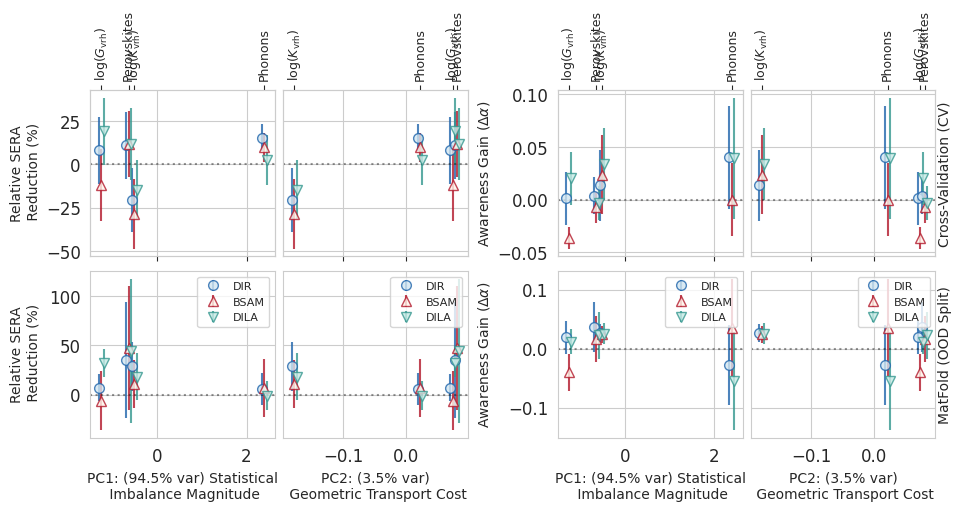

In [49]:
datasets = ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']
methods_to_eval = ['control', 'dir', 'bsam', 'smooth_dila_hpo'] 
print("Extracting Robust Metrics (Computing 95% CI for all runs)...")

dataset_results_map = {}
for dataset in datasets:
    dataset_results_map[dataset] = extract_robust_metrics(
        dataset=dataset, 
        analysers=globals()[f"{dataset}_analysers"], 
    )

master_df = aggregate_datasets(dataset_results_map, meta_data=DATASET_META)

matfold_results_map = {}
for dataset in datasets:
    matfold_results_map[dataset] = extract_robust_metrics(
        dataset=dataset, 
        analysers=globals()[f"matfold_{dataset}_analysers"],
    )
matfold_df = aggregate_datasets(matfold_results_map, meta_data=DATASET_META)

print("\n--- Plotting Analysis Grid ---")
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(9.5, 5), layout='compressed')

# ROW 1: SERA Reduction (%) [Top row -> is_top_row=True]
analyse_method_sensitivity(master_df, ax1, x_metric='PC1', performance='sera', is_top_row=True)
analyse_method_sensitivity(master_df, ax2, x_metric='PC2', performance='sera', is_top_row=True)
analyse_method_sensitivity(master_df, ax3, x_metric='PC1', performance='alpha', is_top_row=True)
analyse_method_sensitivity(master_df, ax4, x_metric='PC2', performance='alpha', is_top_row=True)

ax1.set_ylabel("Relative SERA\n Reduction (%)", fontsize=10)
ax2.set_ylabel("")
ax4.set_ylabel("")

analyse_method_sensitivity(matfold_df, ax5, x_metric='PC1', performance='sera', is_top_row=False)
analyse_method_sensitivity(matfold_df, ax6, x_metric='PC2', performance='sera', is_top_row=False)
analyse_method_sensitivity(matfold_df, ax7, x_metric='PC1', performance='alpha', is_top_row=False)
analyse_method_sensitivity(matfold_df, ax8, x_metric='PC2', performance='alpha', is_top_row=False)

ax5.set_ylabel("Relative SERA\n Reduction (%)", fontsize=10)
ax7.set_ylabel(r"Awareness Gain ($\Delta \alpha$)", fontsize=10) # Retained for column 3

# Link axes for visual alignment
ax2.sharey(ax1)
ax4.sharey(ax3)
ax1.sharex(ax5)
ax2.sharex(ax6)
ax6.sharey(ax5)
ax8.sharey(ax7)
ax3.sharex(ax7)
ax4.sharex(ax8)

# Label outer disables tick labels on inner axes.
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]:
    ax.label_outer()

# Because Column 3 represents a different data split (MatFold), 
# it needs its own y-axis ticks.
for ax in [ax3, ax7]:
    ax.tick_params(labelleft=True)
    ax.yaxis.label.set_visible(True)
    ax.set_ylabel(r"Awareness Gain ($\Delta \alpha$)", fontsize=10)

ax4.text(1.05, 0.5, 'Cross-Validation (CV)', va = 'center', ha = 'center',
         rotation=90, transform=ax4.transAxes, fontsize=10)
ax8.text(1.05, 0.5, 'MatFold (OOD Split)', va = 'center', ha = 'center',
         rotation=90, transform=ax8.transAxes, fontsize=10)
fig.align_ylabels(((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)))
plt.savefig('figs/paper_final/quantitative_alpha_sera.jpg', dpi=600, bbox_inches='tight')
plt.show()

## Method profiling

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import palettable.colorbrewer as ptcb


def load_and_process_profiles(dataset, methods, basedir = 'experiments/profile'):
    method_names = {
        "Control": "control",
        "LDS": "lds",
        "DIR": "dir",
        "DILA": "smooth_dila",
        "BSAM": "bsam",
        "ASAM": "asam"
    }

    METHOD_PATTERNS = {
        method: os.path.join(
            basedir, dataset, method_names[method], "fold_0_*_runtime_profile.csv"
        ) for method in methods
    }
    all_data = []
    
    for method_name, pattern in METHOD_PATTERNS.items():
        # Find all files matching the pattern (supports multiple runs)
        files = glob.glob(pattern)
        
        if not files:
            print(f"Warning: No files found for {method_name} with pattern {pattern}")
            continue
            
        for file in files:
            try:
                df = pd.read_csv(file)
                
                # 1. Filter out the warm-up batch (Epoch 0, Batch 0)
                # This batch includes CUDA initialization and allocator setup overhead
                clean_df = df[~(df['epoch'] == 0)].copy()

                df_group = clean_df.groupby('epoch').agg({
                    'time_ms': 'sum',        # Sum of time_ms
                    'peak_mem_mb': 'max'     # Maximum of peak_mem_mb
                        }).reset_index()
                df_group.columns = ['epoch', 'time_ms', 'peak_mem_mb']
                
                
                # Add metadata
                df_group['Method'] = method_name
                df_group['Run'] = os.path.basename(file) # Track provenance
                
                all_data.append(df_group)
            except Exception as e:
                print(f"Error reading {file}: {e}")

    if not all_data:
        raise ValueError("No data loaded. Check file paths.")
        
    return pd.concat(all_data, ignore_index=True)

def plot_epoch_time(df, ax):
    cmap=ptcb.diverging.RdBu_4.mpl_colors
    sns.boxplot(
        data=df, x="Method", y="time_ms", 
        hue="Method", palette=cmap, ax=ax, showfliers=False
    )
    ax.set_ylabel("Computational Cost per Batch (ms)")
    ax.set_xlabel("")
    
    # Calculate and annotate means
    means_time = df.groupby("Method")["time_ms"].mean()
    for i, method in enumerate(df["Method"].unique()): # Ensure order matches plot
        if method in means_time:
            val = means_time[method]
            # Add text annotation slightly above the median/box
            # (Note: simpler to just print summary stats, but annotation is nice)
            pass
    
def plot_gpu_usage(df, ax):
    # --- Plot 2: GPU Memory Usage ---
    cmap=ptcb.diverging.RdBu_4.mpl_colors
    sns.boxplot(
        data=df, x="Method", y="peak_mem_mb", 
        hue="Method", palette=cmap, ax=ax, showfliers=False
    )
    ax.set_ylabel("Peak GPU Memory Reserved (MB)")
    ax.set_xlabel("")
    

def plot_profiles(df, filename = None):
    # Setup the plot style
    sns.set_theme(style="whitegrid", context="paper")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8))
    
    # --- Plot 1: Runtime per Epoch ---
    plot_epoch_time(df, ax1)

    # --- Plot 2: GPU Memory Usage ---
    plot_gpu_usage(df, ax2)

    plt.tight_layout()
    if filename is None:
        filename = "figs/paper_final/profiling_comparison.jpg"
    plt.savefig(filename, dpi=600)
    print(f"Plot saved to {filename}")
    plt.show()

def print_summary_table(df):
    print("\n--- Performance Summary (Mean ± Std) ---")
    summary = df.groupby("Method").agg({
        "time_ms": ["mean", "std"],
        "peak_mem_mb": ["mean", "std"]
    }).round(2)
    print(summary)

In [45]:
def plot_epoch_time(df, ax):
    sns.boxplot(
        data=df, x="Method", y="time_ms", 
        hue="Method", palette="viridis", ax=ax, showfliers=False
    )

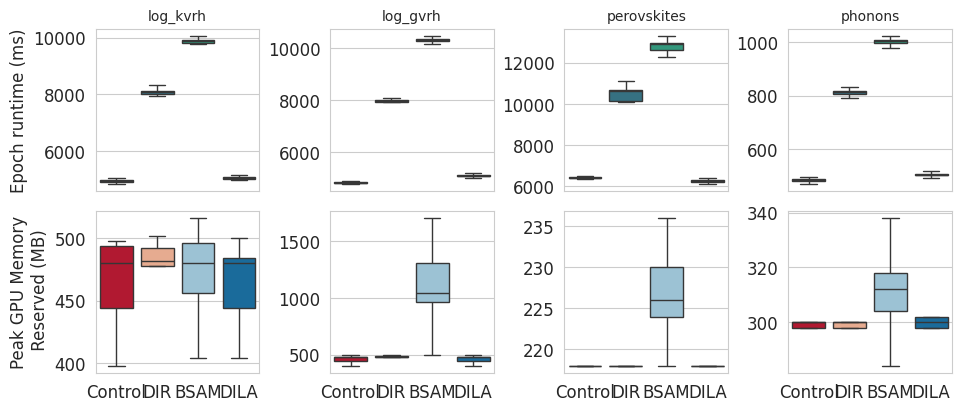

In [47]:
datasets = ['log_kvrh', 'log_gvrh', 'perovskites', 'phonons']
fig, (axes1, axes2) = plt.subplots(2,4, figsize = (9.5, 4), sharex = True, layout = 'compressed')
axes1 = axes1.flatten()
axes2 = axes2.flatten()
for dataset, ax1, ax2 in zip(datasets, axes1, axes2):
    combined_df = load_and_process_profiles(dataset, methods = ["Control", "DIR", "BSAM", "DILA"])
    # print_summary_table(combined_df)
    plot_epoch_time(combined_df, ax1)
    plot_gpu_usage(combined_df, ax2)
    ax1.set_title(dataset, loc = 'center', fontsize = 10)
    ax1.set_ylabel('')
    ax2.set_ylabel('')

axes1[0].set_ylabel('Epoch runtime (ms)')
axes2[0].set_ylabel('Peak GPU Memory\n Reserved (MB)')
# fig.supylabel("Epoch runtime (ms)", fontsize = 10)
plt.savefig('figs/paper_final/methods_profile.jpg', dpi = 600)